In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)

In [3]:
df = pd.read_csv('../data/fully combined/wr_all_weeks.csv')
print(f'Shape: {df.shape}')
print(f'Sezone: {df["season"].min()} – {df["season"].max()}')
df.head()

Shape: (46115, 99)
Sezone: 2015 – 2025


,game_id,receiver_player_id,receiver_player_name,passer_player_id,defteam,targets,receptions,receiving_yards,air_yards,yac,tds,epa,wpa,avg_depth,catch_rate,posteam,team_pass_attempts,team_air_yards,team_epa,air_yard_share,target_share,yards_per_target,def_targets_dev,def_receptions_dev,def_yards_dev,...,targets_Q4,lost_yards_due_to_penalty,yards_wp_<25,yards_wp_25_45,yards_wp_45_55,yards_wp_55_75,yards_wp_>75,yards_wp_NA,receptions_wp_<25,receptions_wp_25_45,receptions_wp_45_55,receptions_wp_55_75,receptions_wp_>75,receptions_wp_NA,targets_wp_<25,targets_wp_25_45,targets_wp_45_55,targets_wp_55_75,targets_wp_>75,targets_wp_NA,home_team,away_team,pregame_spread,pregame_total,season
0,2015_01_BAL_DEN,00-0020337,S.Smith,00-0026158,10,7.0,2.0,13.0,60.0,7.0,0.0,-10.770362,-0.462443,8.571429,0.285714,3,32.0,192.0,-13.765043,0.312500,0.21875,1.857143,1.044305,0.967226,0.904681,...,3.0,0.0,0.0,13.0,0.0,0.0,0.0,0,0.0,2.0,0.0,0.0,0.0,0,0,5,0,2,0,0,10,3,4.5,46.5,2015
1,2015_01_BAL_DEN,00-0024313,O.Daniels,00-0010346,3,2.0,2.0,5.0,2.0,3.0,0.0,-0.248920,-0.006820,1.000000,1.000000,3,32.0,192.0,-13.765043,0.010417,0.06250,2.500000,0.959631,0.973374,0.957703,...,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0,0.0,0.0,0.0,0.0,2.0,0,0,0,0,0,2,0,10,3,4.5,46.5,2015
2,2015_01_BAL_DEN,00-0026237,A.Caldwell,00-0010346,3,1.0,1.0,1.0,0.0,1.0,0.0,-0.664543,-0.022189,0.000000,1.000000,3,32.0,192.0,-13.765043,0.000000,0.03125,1.000000,0.959631,0.973374,0.957703,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,0.0,0.0,0.0,0.0,1.0,0,0,0,0,0,1,0,10,3,4.5,46.5,2015
3,2015_01_BAL_DEN,00-0026373,J.Forsett,00-0026158,10,7.0,4.0,13.0,5.0,13.0,0.0,-1.504406,-0.141163,0.714286,0.571429,3,32.0,192.0,-13.765043,0.026042,0.21875,1.857143,1.044305,0.967226,0.904681,...,3.0,0.0,6.0,0.0,0.0,7.0,0.0,0,3.0,0.0,0.0,1.0,0.0,0,4,2,0,1,0,0,10,3,4.5,46.5,2015
4,2015_01_BAL_DEN,00-0026739,J.Norwood,00-0010346,3,5.0,2.0,25.0,50.0,7.0,0.0,-5.110127,-0.168977,10.000000,0.400000,3,32.0,192.0,-13.765043,0.260417,0.15625,5.000000,0.959631,0.973374,0.957703,...,0.0,0.0,0.0,0.0,0.0,25.0,0.0,0,0.0,0.0,0.0,2.0,0.0,0,0,0,0,2,3,0,10,3,4.5,46.5,2015


In [4]:
df.dtypes.to_frame('dtype').reset_index().rename(columns={'index': 'column'})

,column,dtype
0,game_id,object
1,receiver_player_id,object
2,receiver_player_name,object
3,passer_player_id,object
4,defteam,int64
...,...,...
94,home_team,int64
95,away_team,int64
96,pregame_spread,float64
97,pregame_total,float64


In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})

,missing_count,missing_pct


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
defteam,46115.0,15.965998,9.628853,0.0,8.0,16.0,25.0,32.0
targets,46115.0,4.020362,3.131419,1.0,1.0,3.0,6.0,23.0
receptions,46115.0,2.656554,2.268011,0.0,1.0,2.0,4.0,18.0
receiving_yards,46115.0,29.642047,31.758577,-17.0,7.0,19.0,43.0,300.0
air_yards,46115.0,32.209845,40.914385,-92.0,3.0,17.0,50.0,334.0
...,...,...,...,...,...,...,...,...
home_team,46115.0,15.959861,9.619081,0.0,8.0,16.0,25.0,32.0
away_team,46115.0,15.971831,9.620773,0.0,8.0,16.0,24.0,32.0
pregame_spread,46115.0,1.890914,5.962851,-18.0,-3.0,3.0,6.0,22.0
pregame_total,46115.0,45.339640,4.338047,28.5,42.5,45.0,48.0,63.5


In [7]:
df.groupby('season').size().rename('zapisi').reset_index()

,season,zapisi
0,2015,4314
1,2016,4308
2,2017,4332
3,2018,4304
4,2019,4274
5,2020,4435
6,2021,4616
7,2022,4550
8,2023,4599
9,2024,4465


In [8]:
df['week'] = df['game_id'].str.split('_').str[1].astype(int)
df = df.sort_values(['receiver_player_id', 'season', 'week'], ascending=[True, True, True]).reset_index(drop=True)

print('Tjedni:', sorted(df['week'].unique()))
df.groupby('week').size().rename('zapisi').reset_index()

Tjedni: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22)]


,week,zapisi
0,1,2780
1,2,2826
2,3,2820
3,4,2748
4,5,2566
5,6,2542
6,7,2536
7,8,2569
8,9,2219
9,10,2224


In [9]:
df['weeks_since_last_game'] = (
    df.groupby(['receiver_player_id', 'season'])['week']
      .diff()
      .fillna(1)
      .clip(lower=1)
      .astype(int)
)

print(df['weeks_since_last_game'].value_counts().sort_index().head(10))
df[['receiver_player_id', 'season', 'week', 'weeks_since_last_game']].head(20)

weeks_since_last_game
1     37174
2      5324
3      1535
4       776
5       463
6       280
7       196
8       114
9        85
10       61
Name: count, dtype: int64


,receiver_player_id,season,week,weeks_since_last_game
0,00-0019596,2015,13,1
1,00-0019596,2017,21,1
2,00-0019596,2018,10,1
3,00-0019596,2022,10,1
4,00-0020337,2015,1,1
5,00-0020337,2015,2,1
6,00-0020337,2015,3,1
7,00-0020337,2015,4,1
8,00-0020337,2015,6,2
9,00-0020337,2015,7,1


In [10]:
games_per_player_season = (
    df.groupby(['receiver_player_id', 'season'])
      .size()
      .rename('games_in_season')
      .reset_index()
 )

player_seasons_over_3 = games_per_player_season[games_per_player_season['games_in_season'] > 3].copy()
player_seasons_over_5 = games_per_player_season[games_per_player_season['games_in_season'] > 5].copy()

total_players = games_per_player_season['receiver_player_id'].nunique()
total_player_seasons = len(games_per_player_season)

num_players_over_3 = player_seasons_over_3['receiver_player_id'].nunique()
num_player_seasons_over_3 = len(player_seasons_over_3)

num_players_over_5 = player_seasons_over_5['receiver_player_id'].nunique()
num_player_seasons_over_5 = len(player_seasons_over_5)

pct_players_over_3 = (num_players_over_3 / total_players) * 100
pct_player_seasons_over_3 = (num_player_seasons_over_3 / total_player_seasons) * 100

pct_players_over_5 = (num_players_over_5 / total_players) * 100
pct_player_seasons_over_5 = (num_player_seasons_over_5 / total_player_seasons) * 100

print(f'Ukupno igraca: {total_players}')
print(f'Igraca sa bar jednom sezonom >3 utakmice: {num_players_over_3} ({pct_players_over_3:.2f}%)')
print(f'Igraca sa bar jednom sezonom >5 utakmica: {num_players_over_5} ({pct_players_over_5:.2f}%)')
print('---')
print(f'Ukupno igrac-sezona kombinacija: {total_player_seasons}')
print(f'Kombinacija sa >3 utakmice: {num_player_seasons_over_3} ({pct_player_seasons_over_3:.2f}%)')
print(f'Kombinacija sa >5 utakmica: {num_player_seasons_over_5} ({pct_player_seasons_over_5:.2f}%)')

comparison = pd.DataFrame({
    'metric': [
        'Ukupno igraca',
        'Igraci sa bar jednom sezonom >3',
        'Igraci sa bar jednom sezonom >5',
        'Ukupno igrac-sezona kombinacija',
        'Igrac-sezona kombinacije >3',
        'Igrac-sezona kombinacije >5'
    ],
    'value': [
        total_players,
        num_players_over_3,
        num_players_over_5,
        total_player_seasons,
        num_player_seasons_over_3,
        num_player_seasons_over_5
    ]
})

comparison

Ukupno igraca: 1719
Igraca sa bar jednom sezonom >3 utakmice: 1200 (69.81%)
Igraca sa bar jednom sezonom >5 utakmica: 1077 (62.65%)
---
Ukupno igrac-sezona kombinacija: 5474
Kombinacija sa >3 utakmice: 3970 (72.52%)
Kombinacija sa >5 utakmica: 3432 (62.70%)


,metric,value
0,Ukupno igraca,1719
1,Igraci sa bar jednom sezonom >3,1200
2,Igraci sa bar jednom sezonom >5,1077
3,Ukupno igrac-sezona kombinacija,5474
4,Igrac-sezona kombinacije >3,3970
5,Igrac-sezona kombinacije >5,3432


In [11]:
# Inferred player team from matchup: offense is the opposite side of defteam.
df['player_team_inferred'] = np.where(
    (df['home_team'] == df['defteam']) & (df['away_team'] != df['defteam']),
    df['away_team'],
    np.where(
        (df['away_team'] == df['defteam']) & (df['home_team'] != df['defteam']),
        df['home_team'],
        np.nan
    )
)

prev_team = df.groupby('receiver_player_id')['player_team_inferred'].shift(1)
df['team_changed'] = (
    df['player_team_inferred'].notna()
    & prev_team.notna()
    & (df['player_team_inferred'] != prev_team)
).astype(int)

prev_season = df.groupby('receiver_player_id')['season'].shift(1)
df['is_new_season'] = (
    prev_season.notna()
    & (df['season'] != prev_season)
).astype(int)

unknown_team_rows = df['player_team_inferred'].isna().sum()
print(f'Rows with unresolved inferred team: {unknown_team_rows}')
print('team_changed distribution:')
print(df['team_changed'].value_counts(dropna=False).sort_index())
print('is_new_season distribution:')
print(df['is_new_season'].value_counts(dropna=False).sort_index())

df.loc[
    (df['team_changed'] == 1) | (df['is_new_season'] == 1),
    ['receiver_player_id', 'season', 'week', 'player_team_inferred', 'team_changed', 'is_new_season']
].head(20)

Rows with unresolved inferred team: 0
team_changed distribution:
team_changed
0    44982
1     1133
Name: count, dtype: int64
is_new_season distribution:
is_new_season
0    42360
1     3755
Name: count, dtype: int64


,receiver_player_id,season,week,player_team_inferred,team_changed,is_new_season
1,00-0019596,2017,21,22.0,0,1
2,00-0019596,2018,10,22.0,0,1
3,00-0019596,2022,10,30.0,1,1
11,00-0020337,2016,1,3.0,0,1
37,00-0021547,2016,1,18.0,0,1
50,00-0021547,2017,1,18.0,0,1
66,00-0021547,2018,1,18.0,0,1
100,00-0022044,2016,1,31.0,1,1
120,00-0022084,2016,1,11.0,1,1
153,00-0022127,2016,1,9.0,0,1


In [12]:
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
non_numeric_cols = df.select_dtypes(exclude=['number']).columns.tolist()

print(f"Ukupan broj kolona: {len(df.columns)}")
print(f"Numericke kolone ({len(numeric_cols)}):")
print(numeric_cols)
print()
print(f"Nenumericke kolone ({len(non_numeric_cols)}):")
print(non_numeric_cols)

Ukupan broj kolona: 104
Numericke kolone (100):
['defteam', 'targets', 'receptions', 'receiving_yards', 'air_yards', 'yac', 'tds', 'epa', 'wpa', 'avg_depth', 'catch_rate', 'posteam', 'team_pass_attempts', 'team_air_yards', 'team_epa', 'air_yard_share', 'target_share', 'yards_per_target', 'def_targets_dev', 'def_receptions_dev', 'def_yards_dev', 'def_tds_dev', 'def_epa_dev', 'red_zone_targets', 'end_zone_targets', 'third_down_targets', 'fourth_down_targets', 'high_leverage_targets', 'qb_completions', 'qb_attempts', 'qb_air_yards', 'qb_cpoe', 'qb_comp_pct', 'avg_score_diff', 'avg_quarter', 'adot', 'yac_per_reception', 'td_rate', 'explosive_plays', 'first_downs', 'trailing_pct', 'leading_pct', 'wp_var', 'target_share_std', 'surface', 'is_dome', 'is_rain', 'is_snow', 'is_clear', 'temp_f', 'humidity_pct', 'wind_mph', 'success_rate', 'big_play_rate', 'reception_std', 'second_and_long_targets', 'third_and_medium_targets', 'avg_start_yardline', 'avg_target_depth_vs_qb', 'yards_Q1', 'yards_Q2',

In [13]:
# STEP 5/6/8/9 — Leakage-safe feature engineering

work_df = df.copy().sort_values(['receiver_player_id', 'season', 'week']).reset_index(drop=True)

# Align WP column names with the requested naming convention.
wp_rename_map = {
    'yards_wp_<25': 'yards_wp_less_than_25',
    'yards_wp_>75': 'yards_wp_greater_than_75',
    'receptions_wp_<25': 'receptions_wp_less_than_25',
    'receptions_wp_>75': 'receptions_wp_greater_than_75',
    'targets_wp_<25': 'targets_wp_less_than_25',
    'targets_wp_>75': 'targets_wp_greater_than_75',
}
work_df = work_df.rename(columns={k: v for k, v in wp_rename_map.items() if k in work_df.columns})

# STEP 8 — previous-season career features.
season_career = (
    work_df.groupby(['receiver_player_id', 'season'], as_index=False)
    .agg(
        avg_yards=('receiving_yards', 'mean'),
        avg_target_share=('target_share', 'mean'),
        avg_epa=('epa', 'mean'),
        avg_air_yard_share=('air_yard_share', 'mean'),
        avg_catch_rate=('catch_rate', 'mean'),
        games_played=('game_id', 'count')
    )
    .sort_values(['receiver_player_id', 'season'])
)

for c in ['avg_yards', 'avg_target_share', 'avg_epa', 'avg_air_yard_share', 'avg_catch_rate', 'games_played']:
    season_career[f'{c}_last_season'] = season_career.groupby('receiver_player_id')[c].shift(1)

season_career = season_career[[
    'receiver_player_id', 'season',
    'avg_yards_last_season',
    'avg_target_share_last_season',
    'avg_epa_last_season',
    'avg_air_yard_share_last_season',
    'avg_catch_rate_last_season',
    'games_played_last_season'
]].rename(columns={
    'avg_yards_last_season': 'career_avg_yards_last_season',
    'avg_target_share_last_season': 'career_avg_target_share_last_season',
    'avg_epa_last_season': 'career_avg_epa_last_season',
    'avg_air_yard_share_last_season': 'career_avg_air_yard_share_last_season',
    'avg_catch_rate_last_season': 'career_avg_catch_rate_last_season',
    'games_played_last_season': 'career_games_last_season',
})

work_df = work_df.merge(season_career, on=['receiver_player_id', 'season'], how='left')
career_cols = [
    'career_avg_yards_last_season',
    'career_avg_target_share_last_season',
    'career_avg_epa_last_season',
    'career_avg_air_yard_share_last_season',
    'career_avg_catch_rate_last_season',
    'career_games_last_season',
]
work_df[career_cols] = work_df[career_cols].fillna(0)

# STEP 9 — lag1, roll3, roll5 from previous games only (shift(1) before rolling).
rolling_source_cols = [
    'targets', 'receptions', 'air_yards', 'yac', 'tds', 'epa', 'wpa', 'catch_rate',
    'avg_depth', 'adot', 'yac_per_reception', 'td_rate', 'explosive_plays', 'first_downs',
    'yards_per_target', 'team_pass_attempts', 'team_air_yards', 'team_epa', 'air_yard_share',
    'target_share', 'qb_completions', 'qb_attempts', 'qb_air_yards', 'qb_cpoe', 'qb_comp_pct',
    'avg_score_diff', 'trailing_pct', 'leading_pct', 'avg_quarter', 'success_rate',
    'big_play_rate', 'avg_start_yardline', 'red_zone_targets', 'end_zone_targets',
    'third_down_targets', 'fourth_down_targets', 'high_leverage_targets',
    'second_and_long_targets', 'third_and_medium_targets', 'wp_var', 'target_share_std',
    'reception_std', 'def_targets_dev', 'def_receptions_dev', 'def_yards_dev', 'def_tds_dev',
    'def_epa_dev', 'yards_Q1', 'yards_Q2', 'yards_Q3', 'yards_Q4', 'receptions_Q1',
    'receptions_Q2', 'receptions_Q3', 'receptions_Q4', 'targets_Q1', 'targets_Q2',
    'targets_Q3', 'targets_Q4', 'lost_yards_due_to_penalty', 'yards_wp_less_than_25',
    'yards_wp_25_45', 'yards_wp_45_55', 'yards_wp_55_75', 'yards_wp_greater_than_75',
    'receptions_wp_less_than_25', 'receptions_wp_25_45', 'receptions_wp_45_55',
    'receptions_wp_55_75', 'receptions_wp_greater_than_75', 'targets_wp_less_than_25',
    'targets_wp_25_45', 'targets_wp_45_55', 'targets_wp_55_75', 'targets_wp_greater_than_75',
    'weeks_since_last_game'
]
available_roll_cols = [c for c in rolling_source_cols if c in work_df.columns]

grp = work_df.groupby(['receiver_player_id', 'season'], sort=False)
derived_roll_cols = []
for col in available_roll_cols:
    work_df[f'{col}_lag1'] = grp[col].transform(lambda s: s.shift(1))
    work_df[f'{col}_roll3'] = grp[col].transform(lambda s: s.shift(1).rolling(window=3, min_periods=1).mean())
    work_df[f'{col}_roll5'] = grp[col].transform(lambda s: s.shift(1).rolling(window=5, min_periods=1).mean())
    derived_roll_cols.extend([f'{col}_lag1', f'{col}_roll3', f'{col}_roll5'])

# Drop raw in-game columns used for rolling to prevent leakage.
work_df = work_df.drop(columns=available_roll_cols)

# STEP 6 direct pre-game features only.
pregame_features = [
    'pregame_spread', 'pregame_total', 'surface', 'is_dome', 'temp_f', 'humidity_pct',
    'wind_mph', 'is_rain', 'is_snow', 'is_clear', 'season', 'week', 'team_changed', 'is_new_season'
]

missing_pregame = [c for c in pregame_features if c not in work_df.columns]
if missing_pregame:
    raise ValueError(f'Missing required pre-game features: {missing_pregame}')

feature_cols = pregame_features + career_cols + derived_roll_cols

# Keep target separately for training, while features remain leakage-safe.
target_col = 'receiving_yards'
model_df = work_df[['receiver_player_id', 'receiver_player_name', 'game_id', target_col] + feature_cols].copy()

print(f'Final model_df shape: {model_df.shape}')
print(f'Number of leakage-safe features: {len(feature_cols)}')
print('Preview feature columns:')
print(feature_cols[:25])
print('...')
print(feature_cols[-10:])
print('\nCareer features head:')
print(model_df[career_cols].head())

Final model_df shape: (46115, 252)
Number of leakage-safe features: 248
Preview feature columns:
['pregame_spread', 'pregame_total', 'surface', 'is_dome', 'temp_f', 'humidity_pct', 'wind_mph', 'is_rain', 'is_snow', 'is_clear', 'season', 'week', 'team_changed', 'is_new_season', 'career_avg_yards_last_season', 'career_avg_target_share_last_season', 'career_avg_epa_last_season', 'career_avg_air_yard_share_last_season', 'career_avg_catch_rate_last_season', 'career_games_last_season', 'targets_lag1', 'targets_roll3', 'targets_roll5', 'receptions_lag1', 'receptions_roll3']
...
['targets_wp_45_55_roll5', 'targets_wp_55_75_lag1', 'targets_wp_55_75_roll3', 'targets_wp_55_75_roll5', 'targets_wp_greater_than_75_lag1', 'targets_wp_greater_than_75_roll3', 'targets_wp_greater_than_75_roll5', 'weeks_since_last_game_lag1', 'weeks_since_last_game_roll3', 'weeks_since_last_game_roll5']

Career features head:
   career_avg_yards_last_season  career_avg_target_share_last_season  career_avg_epa_last_season

In [14]:
# Quick validation checks
print('surface unique values in model_df:', sorted(model_df['surface'].dropna().unique().tolist()))
print(model_df['surface'].value_counts(dropna=False).sort_index())

raw_cols_still_present = [c for c in rolling_source_cols if c in feature_cols]
print('\nRaw rolling-source columns still in feature set (should be empty):')
print(raw_cols_still_present)

print('\nAny duplicated feature names:', len(feature_cols) != len(set(feature_cols)))

surface unique values in model_df: [0, 1, 2, 3, 4, 5, 6]
surface
0     2354
1     1175
2    24373
3     2532
4    11286
5     2589
6     1806
Name: count, dtype: int64

Raw rolling-source columns still in feature set (should be empty):
[]

Any duplicated feature names: False


In [15]:
model_df.iloc[10:21]

,receiver_player_id,receiver_player_name,game_id,receiving_yards,pregame_spread,pregame_total,surface,is_dome,temp_f,humidity_pct,wind_mph,is_rain,is_snow,is_clear,season,week,team_changed,is_new_season,career_avg_yards_last_season,career_avg_target_share_last_season,career_avg_epa_last_season,career_avg_air_yard_share_last_season,career_avg_catch_rate_last_season,career_games_last_season,targets_lag1,...,receptions_wp_45_55_roll5,receptions_wp_55_75_lag1,receptions_wp_55_75_roll3,receptions_wp_55_75_roll5,receptions_wp_greater_than_75_lag1,receptions_wp_greater_than_75_roll3,receptions_wp_greater_than_75_roll5,targets_wp_less_than_25_lag1,targets_wp_less_than_25_roll3,targets_wp_less_than_25_roll5,targets_wp_25_45_lag1,targets_wp_25_45_roll3,targets_wp_25_45_roll5,targets_wp_45_55_lag1,targets_wp_45_55_roll3,targets_wp_45_55_roll5,targets_wp_55_75_lag1,targets_wp_55_75_roll3,targets_wp_55_75_roll5,targets_wp_greater_than_75_lag1,targets_wp_greater_than_75_roll3,targets_wp_greater_than_75_roll5,weeks_since_last_game_lag1,weeks_since_last_game_roll3,weeks_since_last_game_roll5
10,00-0020337,S.Smith,2015_08_SD_BAL,82.0,4.5,50.0,3,0,63.0,72.0,10.0,0,0,1,2015,8,0,0,0.000000,0.00000,0.000000,0.00000,0.000000,0.0,9.0,...,1.400000,0.0,0.333333,1.0,0.0,0.000000,0.00,9.0,4.666667,4.60,0.0,1.666667,3.200000,0.0,1.333333,2.200000,0.0,0.666667,1.4,0.0,0.333333,0.40,1.0,1.333333,1.2
11,00-0020337,S.Smith,2016_01_BUF_BAL,19.0,3.0,44.5,2,0,84.0,44.0,8.0,0,0,1,2016,1,0,1,95.714286,0.26336,3.202514,0.30797,0.602384,7.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,00-0020337,S.Smith,2016_02_BAL_CLE,64.0,-4.0,42.0,2,0,74.0,70.0,7.0,0,0,1,2016,2,0,0,95.714286,0.26336,3.202514,0.30797,0.602384,7.0,8.0,...,0.000000,4.0,4.000000,4.0,1.0,1.000000,1.00,0.0,0.000000,0.00,0.0,0.000000,0.000000,0.0,0.000000,0.000000,7.0,7.000000,7.0,1.0,1.000000,1.00,1.0,1.000000,1.0
13,00-0020337,S.Smith,2016_03_BAL_JAX,87.0,-1.0,45.0,2,0,88.0,0.0,8.0,0,0,1,2016,3,0,0,95.714286,0.26336,3.202514,0.30797,0.602384,7.0,6.0,...,0.000000,0.0,2.000000,2.0,0.0,0.500000,0.50,0.0,0.000000,0.00,6.0,3.000000,3.000000,0.0,0.000000,0.000000,0.0,3.500000,3.5,0.0,0.500000,0.50,1.0,1.000000,1.0
14,00-0020337,S.Smith,2016_04_OAK_BAL,111.0,3.5,45.0,2,0,65.0,84.0,2.0,0,0,1,2016,4,0,0,95.714286,0.26336,3.202514,0.30797,0.602384,7.0,11.0,...,0.666667,2.0,2.000000,2.0,2.0,1.000000,1.00,0.0,0.000000,0.00,2.0,2.666667,2.666667,2.0,0.666667,0.666667,5.0,4.000000,4.0,2.0,1.000000,1.00,1.0,1.000000,1.0
15,00-0020337,S.Smith,2016_05_WAS_BAL,29.0,4.0,44.5,2,0,62.0,53.0,16.0,0,0,1,2016,5,0,0,95.714286,0.26336,3.202514,0.30797,0.602384,7.0,12.0,...,1.500000,0.0,0.666667,1.5,0.0,0.666667,0.75,3.0,1.000000,0.75,1.0,3.000000,2.250000,8.0,3.333333,2.500000,0.0,1.666667,3.0,0.0,0.666667,0.75,1.0,1.000000,1.0
16,00-0020337,S.Smith,2016_09_PIT_BAL,47.0,-3.5,46.0,2,0,65.0,28.0,15.0,0,0,1,2016,9,0,0,95.714286,0.26336,3.202514,0.30797,0.602384,7.0,3.0,...,1.200000,1.0,1.000000,1.4,2.0,1.333333,1.00,0.0,1.000000,0.60,0.0,1.000000,1.800000,0.0,3.333333,2.000000,1.0,2.000000,2.6,2.0,1.333333,1.00,1.0,1.000000,1.0
17,00-0020337,S.Smith,2016_10_CLE_BAL,60.0,7.5,44.0,2,0,54.0,48.0,3.0,0,0,1,2016,10,0,0,95.714286,0.26336,3.202514,0.30797,0.602384,7.0,8.0,...,1.200000,3.0,1.333333,1.2,0.0,0.666667,0.80,0.0,1.000000,0.60,1.0,0.666667,2.000000,1.0,3.000000,2.200000,4.0,1.666667,2.0,2.0,1.333333,1.20,4.0,2.000000,1.6
18,00-0020337,S.Smith,2016_11_BAL_DAL,99.0,7.0,44.5,5,0,0.0,0.0,0.0,0,0,1,2016,11,0,0,95.714286,0.26336,3.202514,0.30797,0.602384,7.0,7.0,...,1.400000,3.0,2.333333,1.8,1.0,1.000000,1.00,0.0,0.000000,0.60,0.0,0.333333,0.800000,2.0,1.000000,2.600000,3.0,2.666667,2.6,2.0,2.000000,1.60,1.0,2.000000,1.6
19,00-0020337,S.Smith,2016_12_CIN_BAL,20.0,3.5,42.0,2,0,50.0,37.0,12.0,0,0,1,2016,12,0,0,95.714286,0.26336,3.202514,0.30797,0.602384,7.0,9.0,...,1.200000,0.0,2.000000,1.4,0.0,0.333333,0.60,5.0,1.666667,1.60,3.0,1.333333,1.000000,1.0,1.333333,2.400000

In [16]:
# Validation check for one player: all seasons and all games
player_summary = (
    model_df.groupby(['receiver_player_id', 'receiver_player_name'])
    .size()
    .reset_index(name='num_games')
    .sort_values('num_games', ascending=False)
)

# Pick one player with many games so the check is meaningful.
chosen_player_id = player_summary.iloc[0]['receiver_player_id']
chosen_player_name = player_summary.iloc[0]['receiver_player_name']

player_rows = (
    model_df[model_df['receiver_player_id'] == chosen_player_id]
    .sort_values(['season', 'week'])
    .reset_index(drop=True)
)

player_seasons = player_rows['season'].drop_duplicates().tolist()
player_games = player_rows['game_id'].tolist()

print(f'Player: {chosen_player_name} ({chosen_player_id})')
print(f'Ukupno utakmica: {len(player_games)}')
print(f'Sve sezone ({len(player_seasons)}): {player_seasons}')
print('\nSve utakmice (game_id):')
print(player_games)

# Show all columns and more rows for inspection.
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 220)
player_rows.head(50)

Player: T.Kelce (00-0030506)
Ukupno utakmica: 191
Sve sezone (11): [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

Sve utakmice (game_id):
['2015_01_KC_HOU', '2015_02_DEN_KC', '2015_03_KC_GB', '2015_04_KC_CIN', '2015_05_CHI_KC', '2015_06_KC_MIN', '2015_07_PIT_KC', '2015_08_DET_KC', '2015_10_KC_DEN', '2015_11_KC_SD', '2015_12_BUF_KC', '2015_13_KC_OAK', '2015_14_SD_KC', '2015_15_KC_BAL', '2015_16_CLE_KC', '2015_17_OAK_KC', '2015_18_KC_HOU', '2015_19_KC_NE', '2016_01_SD_KC', '2016_02_KC_HOU', '2016_03_NYJ_KC', '2016_04_KC_PIT', '2016_06_KC_OAK', '2016_07_NO_KC', '2016_08_KC_IND', '2016_09_JAX_KC', '2016_10_KC_CAR', '2016_11_TB_KC', '2016_12_KC_DEN', '2016_13_KC_ATL', '2016_14_OAK_KC', '2016_15_TEN_KC', '2016_16_DEN_KC', '2016_17_KC_SD', '2016_19_PIT_KC', '2017_01_KC_NE', '2017_02_PHI_KC', '2017_03_KC_LAC', '2017_04_WAS_KC', '2017_05_KC_HOU', '2017_06_PIT_KC', '2017_07_KC_OAK', '2017_08_DEN_KC', '2017_09_KC_DAL', '2017_11_KC_NYG', '2017_12_BUF_KC', '2017_13_KC_NYJ', '20

,receiver_player_id,receiver_player_name,game_id,receiving_yards,pregame_spread,pregame_total,surface,is_dome,temp_f,humidity_pct,wind_mph,is_rain,is_snow,is_clear,season,week,team_changed,is_new_season,career_avg_yards_last_season,career_avg_target_share_last_season,career_avg_epa_last_season,career_avg_air_yard_share_last_season,career_avg_catch_rate_last_season,career_games_last_season,targets_lag1,targets_roll3,targets_roll5,receptions_lag1,receptions_roll3,receptions_roll5,air_yards_lag1,air_yards_roll3,air_yards_roll5,yac_lag1,yac_roll3,yac_roll5,tds_lag1,tds_roll3,tds_roll5,epa_lag1,epa_roll3,epa_roll5,wpa_lag1,wpa_roll3,wpa_roll5,catch_rate_lag1,catch_rate_roll3,catch_rate_roll5,avg_depth_lag1,avg_depth_roll3,avg_depth_roll5,adot_lag1,adot_roll3,adot_roll5,yac_per_reception_lag1,yac_per_reception_roll3,yac_per_reception_roll5,td_rate_lag1,td_rate_roll3,td_rate_roll5,explosive_plays_lag1,explosive_plays_roll3,explosive_plays_roll5,first_downs_lag1,first_downs_roll3,first_downs_roll5,yards_per_target_lag1,yards_per_target_roll3,yards_per_target_roll5,team_pass_attempts_lag1,team_pass_attempts_roll3,team_pass_attempts_roll5,team_air_yards_lag1,team_air_yards_roll3,team_air_yards_roll5,team_epa_lag1,team_epa_roll3,team_epa_roll5,air_yard_share_lag1,air_yard_share_roll3,air_yard_share_roll5,target_share_lag1,target_share_roll3,target_share_roll5,qb_completions_lag1,qb_completions_roll3,qb_completions_roll5,qb_attempts_lag1,qb_attempts_roll3,qb_attempts_roll5,qb_air_yards_lag1,qb_air_yards_roll3,qb_air_yards_roll5,qb_cpoe_lag1,qb_cpoe_roll3,qb_cpoe_roll5,qb_comp_pct_lag1,qb_comp_pct_roll3,qb_comp_pct_roll5,avg_score_diff_lag1,avg_score_diff_roll3,avg_score_diff_roll5,trailing_pct_lag1,trailing_pct_roll3,trailing_pct_roll5,leading_pct_lag1,leading_pct_roll3,leading_pct_roll5,avg_quarter_lag1,avg_quarter_roll3,avg_quarter_roll5,success_rate_lag1,success_rate_roll3,success_rate_roll5,big_play_rate_lag1,big_play_rate_roll3,big_play_rate_roll5,avg_start_yardline_lag1,avg_start_yardline_roll3,avg_start_yardline_roll5,red_zone_targets_lag1,red_zone_targets_roll3,red_zone_targets_roll5,end_zone_targets_lag1,end_zone_targets_roll3,end_zone_targets_roll5,third_down_targets_lag1,third_down_targets_roll3,third_down_targets_roll5,fourth_down_targets_lag1,fourth_down_targets_roll3,fourth_down_targets_roll5,high_leverage_targets_lag1,high_leverage_targets_roll3,high_leverage_targets_roll5,second_and_long_targets_lag1,second_and_long_targets_roll3,second_and_long_targets_roll5,third_and_medium_targets_lag1,third_and_medium_targets_roll3,third_and_medium_targets_roll5,wp_var_lag1,wp_var_roll3,wp_var_roll5,target_share_std_lag1,target_share_std_roll3,target_share_std_roll5,reception_std_lag1,reception_std_roll3,reception_std_roll5,def_targets_dev_lag1,def_targets_dev_roll3,def_targets_dev_roll5,def_receptions_dev_lag1,def_receptions_dev_roll3,def_receptions_dev_roll5,def_yards_dev_lag1,def_yards_dev_roll3,def_yards_dev_roll5,def_tds_dev_lag1,def_tds_dev_roll3,def_tds_dev_roll5,def_epa_dev_lag1,def_epa_dev_roll3,def_epa_dev_roll5,yards_Q1_lag1,yards_Q1_roll3,yards_Q1_roll5,yards_Q2_lag1,yards_Q2_roll3,yards_Q2_roll5,yards_Q3_lag1,yards_Q3_roll3,yards_Q3_roll5,yards_Q4_lag1,yards_Q4_roll3,yards_Q4_roll5,receptions_Q1_lag1,receptions_Q1_roll3,receptions_Q1_roll5,receptions_Q2_lag1,receptions_Q2_roll3,receptions_Q2_roll5,receptions_Q3_lag1,receptions_Q3_roll3,receptions_Q3_roll5,receptions_Q4_lag1,receptions_Q4_roll3,receptions_Q4_roll5,targets_Q1_lag1,targets_Q1_roll3,targets_Q1_roll5,targets_Q2_lag1,targets_Q2_roll3,targets_Q2_roll5,targets_Q3_lag1,targets_Q3_roll3,targets_Q3_roll5,targets_Q4_lag1,targets_Q4_roll3,targets_Q4_roll5,lost_yards_due_to_penalty_lag1,lost_yards_due_to_penalty_roll3,lost_yards_due_to_penalty_roll5,yards_wp_less_than_25_lag1,yards_wp_less_than_25_roll3,yards_wp_less_than_25_roll5,yards_wp_25_45_lag1,yards_wp_25_45_roll3,yards_wp_25_45_roll5,yards_wp_45_55_lag1,yards_wp_45_55_roll3,yards_wp_45_55_roll5,yards_wp_55_75_la

In [17]:
# Prosecna statistika za T.Kelce u sezoni 2015
player_id = '00-0030506'
season_year = 2015

kelce_season = (
    df[(df['receiver_player_id'] == player_id) & (df['season'] == season_year)]
    .sort_values('week')
    .copy()
)

print(f"Igrac: {kelce_season['receiver_player_name'].iloc[0]} ({player_id})")
print(f"Sezona: {season_year}")
print(f"Broj utakmica: {len(kelce_season)}")
print(f"Nedelje: {kelce_season['week'].tolist()}")

summary = {
    'games_played': len(kelce_season),
    'targets_total': kelce_season['targets'].sum(),
    'receptions_total': kelce_season['receptions'].sum(),
    'receiving_yards_total': kelce_season['receiving_yards'].sum(),
    'tds_total': kelce_season['tds'].sum(),
    'air_yards_total': kelce_season['air_yards'].sum(),
    'yac_total': kelce_season['yac'].sum(),
    'targets_per_game': kelce_season['targets'].mean(),
    'receptions_per_game': kelce_season['receptions'].mean(),
    'receiving_yards_per_game': kelce_season['receiving_yards'].mean(),
    'tds_per_game': kelce_season['tds'].mean(),
    'air_yards_per_game': kelce_season['air_yards'].mean(),
    'yac_per_game': kelce_season['yac'].mean(),
    'catch_rate_avg': kelce_season['catch_rate'].mean(),
    'yards_per_target_avg': kelce_season['yards_per_target'].mean(),
    'target_share_avg': kelce_season['target_share'].mean(),
    'air_yard_share_avg': kelce_season['air_yard_share'].mean(),
    'epa_avg': kelce_season['epa'].mean(),
    'wpa_avg': kelce_season['wpa'].mean(),
    'adot_avg': kelce_season['adot'].mean(),
}

season_summary = pd.DataFrame(
    {'metric': list(summary.keys()), 'value': list(summary.values())}
)
season_summary['value'] = season_summary['value'].astype(float).round(3)
season_summary

Igrac: T.Kelce (00-0030506)
Sezona: 2015
Broj utakmica: 18
Nedelje: [1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]


,metric,value
0,games_played,18.000
1,targets_total,124.000
2,receptions_total,86.000
3,receiving_yards_total,1026.000
4,tds_total,5.000
5,air_yards_total,695.000
6,yac_total,609.000
7,targets_per_game,6.889
8,receptions_per_game,4.778
9,receiving_yards_per_game,57.000


In [18]:
# STEP 10/11/12 — data sufficiency filter, no-history drop, and target transform

model_df_step = model_df.copy()

# STEP 10: keep only player-season groups with at least 6 games
player_season_games = (
    model_df_step.groupby(['receiver_player_id', 'season'])
    .size()
    .rename('games_in_season')
    .reset_index()
)

valid_player_seasons = player_season_games[player_season_games['games_in_season'] >= 6][
    ['receiver_player_id', 'season']
]

rows_before_step10 = len(model_df_step)
model_df_step = model_df_step.merge(valid_player_seasons, on=['receiver_player_id', 'season'], how='inner')
rows_after_step10 = len(model_df_step)

# STEP 11: drop rows with no prior in-season history (all lag1 features are NaN)
lag1_cols = [c for c in model_df_step.columns if c.endswith('_lag1')]
if not lag1_cols:
    raise ValueError('No lag1 columns found. Step 9 must run before Step 11.')

no_history_mask = model_df_step[lag1_cols].isna().all(axis=1)
rows_before_step11 = len(model_df_step)
model_df_step = model_df_step.loc[~no_history_mask].copy()
rows_after_step11 = len(model_df_step)

# STEP 12: log1p target transform for training
# Receiving yards can be negative on some plays, so clip to 0 before log1p.
neg_target_rows = int((model_df_step['receiving_yards'] < 0).sum())
model_df_step['receiving_yards_log'] = np.log1p(model_df_step['receiving_yards'].clip(lower=0))

# Final modeling dataframe for training/evaluation workflow
model_df_final = model_df_step.copy()

print('STEP 10 — Filter player-seasons with >= 6 games')
print(f'Rows before: {rows_before_step10}, rows after: {rows_after_step10}, removed: {rows_before_step10 - rows_after_step10}')
print()
print('STEP 11 — Drop no-history rows (all lag1 are NaN)')
print(f'Rows before: {rows_before_step11}, rows after: {rows_after_step11}, removed: {rows_before_step11 - rows_after_step11}')
print()
print('STEP 12 — Target transform')
print(f'Negative receiving_yards rows clipped to 0 before log1p: {neg_target_rows}')
print('Columns now include receiving_yards_log:', 'receiving_yards_log' in model_df_final.columns)

# Reminder for evaluation: convert predictions back to original yards scale
print('\nFor evaluation use: y_pred = np.expm1(y_pred_log)')
print('All metrics should be computed on receiving_yards scale (original units).')

model_df_final[['receiver_player_id', 'season', 'week', 'receiving_yards', 'receiving_yards_log']].head(15)

STEP 10 — Filter player-seasons with >= 6 games
Rows before: 46115, rows after: 41100, removed: 5015

STEP 11 — Drop no-history rows (all lag1 are NaN)
Rows before: 41100, rows after: 37668, removed: 3432

STEP 12 — Target transform
Negative receiving_yards rows clipped to 0 before log1p: 438
Columns now include receiving_yards_log: True

For evaluation use: y_pred = np.expm1(y_pred_log)
All metrics should be computed on receiving_yards scale (original units).


,receiver_player_id,season,week,receiving_yards,receiving_yards_log
1,00-0020337,2015,2,150.0,5.017280
2,00-0020337,2015,3,186.0,5.231109
3,00-0020337,2015,4,24.0,3.218876
4,00-0020337,2015,6,137.0,4.927254
5,00-0020337,2015,7,78.0,4.369448
6,00-0020337,2015,8,82.0,4.418841
8,00-0020337,2016,2,64.0,4.174387
9,00-0020337,2016,3,87.0,4.477337
10,00-0020337,2016,4,111.0,4.718499
11,00-0020337,2016,5,29.0,3.401197


In [19]:
# STEP 13 — strict temporal split by season

train_seasons = list(range(2015, 2022))  # 2015-2021
val_seasons = [2022, 2023]
test_seasons = [2024, 2025]

train_df = model_df_final[model_df_final['season'].isin(train_seasons)].copy()
val_df = model_df_final[model_df_final['season'].isin(val_seasons)].copy()
test_df = model_df_final[model_df_final['season'].isin(test_seasons)].copy()

feature_columns = [
    c for c in model_df_final.columns
    if c not in ['receiver_player_id', 'receiver_player_name', 'game_id', 'receiving_yards', 'receiving_yards_log']
]

print('STEP 13 — TRAIN / VALIDATION / TEST (temporal by season)')
print(f'Train seasons: {train_seasons}')
print(f'Validation seasons: {val_seasons}')
print(f'Test seasons: {test_seasons}')
print()
print(f'Train shape: {train_df.shape}')
print(f'Validation shape: {val_df.shape}')
print(f'Test shape: {test_df.shape}')
print(f'Number of features: {len(feature_columns)}')

# Optional matrices for training
X_train = train_df[feature_columns].copy()
y_train = train_df['receiving_yards_log'].copy()
X_val = val_df[feature_columns].copy()
y_val = val_df['receiving_yards_log'].copy()
X_test = test_df[feature_columns].copy()
y_test = test_df['receiving_yards_log'].copy()

print('\nX/y shapes:')
print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_val: {X_val.shape}, y_val: {y_val.shape}')
print(f'X_test: {X_test.shape}, y_test: {y_test.shape}')

STEP 13 — TRAIN / VALIDATION / TEST (temporal by season)
Train seasons: [2015, 2016, 2017, 2018, 2019, 2020, 2021]
Validation seasons: [2022, 2023]
Test seasons: [2024, 2025]

Train shape: (25147, 253)
Validation shape: (7680, 253)
Test shape: (4841, 253)
Number of features: 248

X/y shapes:
X_train: (25147, 248), y_train: (25147,)
X_val: (7680, 248), y_val: (7680,)
X_test: (4841, 248), y_test: (4841,)


In [20]:
# Missing values report

def missing_report(name, data, top_n=10):
    miss = data.isna().sum()
    miss = miss[miss > 0].sort_values(ascending=False)
    total_missing = int(miss.sum())
    cols_with_missing = int((data.isna().sum() > 0).sum())
    pct_cells_missing = (total_missing / (data.shape[0] * data.shape[1])) * 100 if data.size else 0

    print(f'=== {name} ===')
    print(f'Shape: {data.shape}')
    print(f'Total missing cells: {total_missing}')
    print(f'Columns with missing: {cols_with_missing}')
    print(f'% missing cells: {pct_cells_missing:.4f}%')

    if len(miss) == 0:
        print('No missing values.')
        print()
        return

    top = miss.head(top_n).to_frame('missing_count')
    top['missing_pct'] = (top['missing_count'] / len(data) * 100).round(3)
    print(f'Top {min(top_n, len(top))} columns with missing:')
    print(top)
    print()

missing_report('df (raw + engineered helper cols)', df)
missing_report('model_df (after Step 5/6/8/9)', model_df)
missing_report('model_df_final (after Step 10/11/12)', model_df_final)
missing_report('X_train', X_train)
missing_report('X_val', X_val)
missing_report('X_test', X_test)

=== df (raw + engineered helper cols) ===
Shape: (46115, 104)
Total missing cells: 0
Columns with missing: 0
% missing cells: 0.0000%
No missing values.

=== model_df (after Step 5/6/8/9) ===
Shape: (46115, 252)
Total missing cells: 1248072
Columns with missing: 228
% missing cells: 10.7398%
Top 10 columns with missing:
                  missing_count  missing_pct
targets_lag1               5474        11.87
targets_roll3              5474        11.87
targets_roll5              5474        11.87
receptions_lag1            5474        11.87
receptions_roll3           5474        11.87
receptions_roll5           5474        11.87
air_yards_lag1             5474        11.87
air_yards_roll3            5474        11.87
air_yards_roll5            5474        11.87
yac_lag1                   5474        11.87

=== model_df_final (after Step 10/11/12) ===
Shape: (37668, 253)
Total missing cells: 0
Columns with missing: 0
% missing cells: 0.0000%
No missing values.

=== X_train ===
Shape: (2

In [21]:
# STEP 15 — Feature scaling (fit on train only)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit ONLY on training features
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

# Apply the fitted scaler to validation and test
X_val_scaled = pd.DataFrame(
    scaler.transform(X_val),
    columns=X_val.columns,
    index=X_val.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print('STEP 15 — StandardScaler (fit on train only)')
print(f'X_train_scaled shape: {X_train_scaled.shape}')
print(f'X_val_scaled shape: {X_val_scaled.shape}')
print(f'X_test_scaled shape: {X_test_scaled.shape}')

# Quick sanity checks
train_mean_abs = float(np.abs(X_train_scaled.mean()).mean())
train_std_mean = float(X_train_scaled.std(ddof=0).mean())
print(f'Avg |mean| across train features (should be near 0): {train_mean_abs:.6f}')
print(f'Avg std across train features (should be near 1): {train_std_mean:.6f}')

STEP 15 — StandardScaler (fit on train only)
X_train_scaled shape: (25147, 248)
X_val_scaled shape: (7680, 248)
X_test_scaled shape: (4841, 248)
Avg |mean| across train features (should be near 0): 0.000000
Avg std across train features (should be near 1): 0.959677


In [22]:
# Detaljno proveriti missing values u scaled datasets

def check_missing_detailed(df_name, df):
    total_cells = df.shape[0] * df.shape[1]
    missing_total = df.isna().sum().sum()
    cols_with_missing = (df.isna().sum() > 0).sum()
    pct_missing = (missing_total / total_cells * 100) if total_cells > 0 else 0
    
    print(f'=== {df_name} ===')
    print(f'Shape: {df.shape}')
    print(f'Total cells: {total_cells}')
    print(f'Total missing: {missing_total}')
    print(f'Columns with missing: {cols_with_missing}')
    print(f'% missing: {pct_missing:.6f}%')
    
    if cols_with_missing > 0:
        print('Columns with missing values:')
        missing_per_col = df.isna().sum()
        print(missing_per_col[missing_per_col > 0])
    else:
        print('✓ NO MISSING VALUES')
    print()

check_missing_detailed('X_train_scaled', X_train_scaled)
check_missing_detailed('X_val_scaled', X_val_scaled)
check_missing_detailed('X_test_scaled', X_test_scaled)

# Provera infinity vrednosti
print('=== Infinity values check ===')
print(f'X_train_scaled inf count: {np.isinf(X_train_scaled.values).sum()}')
print(f'X_val_scaled inf count: {np.isinf(X_val_scaled.values).sum()}')
print(f'X_test_scaled inf count: {np.isinf(X_test_scaled.values).sum()}')


=== X_train_scaled ===
Shape: (25147, 248)
Total cells: 6236456
Total missing: 0
Columns with missing: 0
% missing: 0.000000%
✓ NO MISSING VALUES

=== X_val_scaled ===
Shape: (7680, 248)
Total cells: 1904640
Total missing: 0
Columns with missing: 0
% missing: 0.000000%
✓ NO MISSING VALUES

=== X_test_scaled ===
Shape: (4841, 248)
Total cells: 1200568
Total missing: 0
Columns with missing: 0
% missing: 0.000000%
✓ NO MISSING VALUES

=== Infinity values check ===
X_train_scaled inf count: 0
X_val_scaled inf count: 0
X_test_scaled inf count: 0


In [23]:
# STEP 16 — BUILD SEQUENCE DATA FOR LSTM AND GRU

def build_sequences(scaled_df, target_series, model_df_source, sequence_length=5):
    """
    Build sequences of length 5 from scaled features for LSTM/GRU.
    
    Args:
        scaled_df: Scaled feature DataFrame (X_train_scaled, X_val_scaled, or X_test_scaled)
        target_series: Corresponding target series (y_train, y_val, or y_test)
        model_df_source: Original model_df_final with player_id, season info
        sequence_length: Length of sequences (5 games)
    
    Returns:
        X_sequences: Array of shape (num_samples, 5, num_features)
        y_sequences: Array of targets corresponding to sequences
        indexing: DataFrame with sample_idx, original_row_idx for traceability
    """
    
    # Merge scaled features with metadata
    df_with_meta = scaled_df.copy()
    df_with_meta['receiver_player_id'] = model_df_source['receiver_player_id'].values
    df_with_meta['season'] = model_df_source['season'].values
    df_with_meta['target'] = target_series.values
    df_with_meta['original_idx'] = range(len(df_with_meta))
    
    sequences_list = []
    targets_list = []
    indexing_list = []
    
    # Group by player and season to ensure no boundary crossing
    for (player_id, season), group in df_with_meta.groupby(['receiver_player_id', 'season'], sort=False):
        group_sorted = group.sort_values('original_idx').reset_index(drop=True)
        
        # Get features and targets for this player-season
        features_array = group_sorted[scaled_df.columns].values  # Shape: (num_games, num_features)
        targets_array = group_sorted['target'].values
        original_indices = group_sorted['original_idx'].values
        
        # Sliding window: create sequences of length 5
        num_games = len(group_sorted)
        for i in range(num_games - sequence_length):
            # Sequence: games i, i+1, i+2, i+3, i+4 (5 games)
            seq = features_array[i:i+sequence_length]  # Shape: (5, num_features)
            # Target: game i+5 (the 6th game)
            target = targets_array[i+sequence_length]
            # Original row index of the target
            target_original_idx = original_indices[i+sequence_length]
            
            sequences_list.append(seq)
            targets_list.append(target)
            indexing_list.append({
                'player_id': player_id,
                'season': season,
                'sequence_num': i,
                'target_row_idx': target_original_idx,
                'target_game_num': i+sequence_length
            })
    
    # Convert to numpy arrays
    X_sequences = np.array(sequences_list)  # Shape: (num_samples, 5, num_features)
    y_sequences = np.array(targets_list)    # Shape: (num_samples,)
    indexing_df = pd.DataFrame(indexing_list)
    
    return X_sequences, y_sequences, indexing_df

# Build sequences for train, val, test
print('STEP 16 — BUILD SEQUENCE DATA FOR LSTM AND GRU')
print('=' * 70)

X_train_seq, y_train_seq, train_idx = build_sequences(X_train_scaled, y_train, train_df)
X_val_seq, y_val_seq, val_idx = build_sequences(X_val_scaled, y_val, val_df)
X_test_seq, y_test_seq, test_idx = build_sequences(X_test_scaled, y_test, test_df)

print(f'Training sequences:')
print(f'  X_train_seq shape: {X_train_seq.shape} (samples, sequence_length, features)')
print(f'  y_train_seq shape: {y_train_seq.shape}')
print(f'  Non-sequence train samples: {len(X_train_scaled)}')
print(f'  Sequence-compatible samples: {len(X_train_seq)}')
print(f'  Reduction: {len(X_train_scaled) - len(X_train_seq)} rows (first 5 games per player-season)')
print()

print(f'Validation sequences:')
print(f'  X_val_seq shape: {X_val_seq.shape}')
print(f'  y_val_seq shape: {y_val_seq.shape}')
print(f'  Non-sequence val samples: {len(X_val_scaled)}')
print(f'  Sequence-compatible samples: {len(X_val_seq)}')
print(f'  Reduction: {len(X_val_scaled) - len(X_val_seq)} rows')
print()

print(f'Test sequences:')
print(f'  X_test_seq shape: {X_test_seq.shape}')
print(f'  y_test_seq shape: {y_test_seq.shape}')
print(f'  Non-sequence test samples: {len(X_test_scaled)}')
print(f'  Sequence-compatible samples: {len(X_test_seq)}')
print(f'  Reduction: {len(X_test_scaled) - len(X_test_seq)} rows')
print()

print('Sequence data statistics:')
print(f'  Total sequence samples: {len(X_train_seq) + len(X_val_seq) + len(X_test_seq)}')
print(f'  Features per game: {X_train_seq.shape[2]}')
print(f'  Sequence length: {X_train_seq.shape[1]} games')
print()

# Verify no NaN or infinity in sequences
def check_seq_quality(X_seq, y_seq, name):
    x_nan = np.isnan(X_seq).sum()
    x_inf = np.isinf(X_seq).sum()
    y_nan = np.isnan(y_seq).sum()
    y_inf = np.isinf(y_seq).sum()
    
    print(f'{name}:')
    print(f'  X_seq NaN: {x_nan}, Inf: {x_inf}')
    print(f'  y_seq NaN: {y_nan}, Inf: {y_inf}')
    if x_nan + x_inf + y_nan + y_inf == 0:
        print(f'  ✓ Quality: CLEAN')
    else:
        print(f'  ⚠ Quality: ISSUES DETECTED')
    print()

check_seq_quality(X_train_seq, y_train_seq, 'Train sequences')
check_seq_quality(X_val_seq, y_val_seq, 'Validation sequences')
check_seq_quality(X_test_seq, y_test_seq, 'Test sequences')

print('Sequence data shape summary:')
print(f'  X_train_seq:  {X_train_seq.shape}')
print(f'  X_val_seq:    {X_val_seq.shape}')
print(f'  X_test_seq:   {X_test_seq.shape}')
print(f'  All ready for LSTM/GRU models.')


STEP 16 — BUILD SEQUENCE DATA FOR LSTM AND GRU
Training sequences:
  X_train_seq shape: (13817, 5, 248) (samples, sequence_length, features)
  y_train_seq shape: (13817,)
  Non-sequence train samples: 25147
  Sequence-compatible samples: 13817
  Reduction: 11330 rows (first 5 games per player-season)

Validation sequences:
  X_val_seq shape: (4360, 5, 248)
  y_val_seq shape: (4360,)
  Non-sequence val samples: 7680
  Sequence-compatible samples: 4360
  Reduction: 3320 rows

Test sequences:
  X_test_seq shape: (2331, 5, 248)
  y_test_seq shape: (2331,)
  Non-sequence test samples: 4841
  Sequence-compatible samples: 2331
  Reduction: 2510 rows

Sequence data statistics:
  Total sequence samples: 20508
  Features per game: 248
  Sequence length: 5 games

Train sequences:
  X_seq NaN: 0, Inf: 0
  y_seq NaN: 0, Inf: 0
  ✓ Quality: CLEAN

Validation sequences:
  X_seq NaN: 0, Inf: 0
  y_seq NaN: 0, Inf: 0
  ✓ Quality: CLEAN

Test sequences:
  X_seq NaN: 0, Inf: 0
  y_seq NaN: 0, Inf: 0
  ✓ 

In [24]:
# Strict validation: sequence integrity + STEP 4 identifier exclusion

identifier_cols_step4 = [
    'game_id', 'receiver_player_id', 'receiver_player_name',
    'passer_player_id', 'home_team', 'away_team', 'posteam', 'defteam'
]

def validate_sequences_and_step4(split_name, split_df, X_seq, y_seq, idx_df, feature_cols):
    print(f'===== {split_name.upper()} VALIDATION =====')

    # 1) Expected number of sequences from sliding-window rule N-5 per player-season
    expected_seq = int(
        split_df.groupby(['receiver_player_id', 'season'])
        .size()
        .apply(lambda n: max(n - 5, 0))
        .sum()
    )
    actual_seq = len(X_seq)
    print(f'Expected sequences (sum(N-5)): {expected_seq}')
    print(f'Actual sequences: {actual_seq}')
    print('Sequence count match:', expected_seq == actual_seq)

    # 2) Shape checks: (samples, 5, num_features)
    expected_shape = (expected_seq, 5, len(feature_cols))
    print(f'Expected X_seq shape: {expected_shape}')
    print(f'Actual X_seq shape:   {X_seq.shape}')
    print('Shape match:', X_seq.shape == expected_shape)

    # 3) Target alignment check (y_seq equals receiving_yards_log at target_row_idx)
    source_targets = split_df['receiving_yards_log'].reset_index(drop=True)
    y_from_source = source_targets.iloc[idx_df['target_row_idx'].values].to_numpy()
    target_alignment_ok = np.allclose(y_seq, y_from_source, equal_nan=True)
    print('Target alignment with source rows:', target_alignment_ok)

    # 4) Boundary check via indexing table generated during sequence build
    # Every sequence in idx_df is tagged with one player_id + one season.
    no_boundary_cross = idx_df[['player_id', 'season']].notna().all(axis=1).all()
    print('No player/season boundary crossing marker issues:', bool(no_boundary_cross))

    # 5) Data quality checks
    print('NaN in X_seq:', int(np.isnan(X_seq).sum()))
    print('Inf in X_seq:', int(np.isinf(X_seq).sum()))
    print('NaN in y_seq:', int(np.isnan(y_seq).sum()))
    print('Inf in y_seq:', int(np.isinf(y_seq).sum()))

    all_ok = (
        (expected_seq == actual_seq)
        and (X_seq.shape == expected_shape)
        and target_alignment_ok
        and bool(no_boundary_cross)
        and int(np.isnan(X_seq).sum()) == 0
        and int(np.isinf(X_seq).sum()) == 0
        and int(np.isnan(y_seq).sum()) == 0
        and int(np.isinf(y_seq).sum()) == 0
    )

    print(f'VALIDATION RESULT ({split_name}):', 'PASS' if all_ok else 'FAIL')
    print()
    return all_ok

# STEP 4 validation: identifier columns must never be used as features
print('===== STEP 4 IDENTIFIER EXCLUSION CHECK =====')
step4_in_feature_columns = [c for c in identifier_cols_step4 if c in feature_columns]
step4_in_X_train = [c for c in identifier_cols_step4 if c in X_train.columns]
step4_in_X_train_scaled = [c for c in identifier_cols_step4 if c in X_train_scaled.columns]
step4_in_model_df = [c for c in identifier_cols_step4 if c in model_df.columns]

print('Identifiers present in feature_columns:', step4_in_feature_columns)
print('Identifiers present in X_train:', step4_in_X_train)
print('Identifiers present in X_train_scaled:', step4_in_X_train_scaled)
print('Identifiers present in model_df (for metadata/traceability):', step4_in_model_df)
print()

# Full sequence integrity validation
train_ok = validate_sequences_and_step4('train', train_df, X_train_seq, y_train_seq, train_idx, feature_columns)
val_ok = validate_sequences_and_step4('validation', val_df, X_val_seq, y_val_seq, val_idx, feature_columns)
test_ok = validate_sequences_and_step4('test', test_df, X_test_seq, y_test_seq, test_idx, feature_columns)

overall_seq_ok = train_ok and val_ok and test_ok
step4_ok = (len(step4_in_feature_columns) == 0 and len(step4_in_X_train) == 0 and len(step4_in_X_train_scaled) == 0)

print('===== FINAL STATUS =====')
print('Sequence construction ready for GRU/LSTM:', overall_seq_ok)
print('STEP 4 rule satisfied for model features:', step4_ok)

if not step4_ok:
    print('WARNING: Some STEP 4 identifiers leaked into model features.')


===== STEP 4 IDENTIFIER EXCLUSION CHECK =====
Identifiers present in feature_columns: []
Identifiers present in X_train: []
Identifiers present in X_train_scaled: []
Identifiers present in model_df (for metadata/traceability): ['game_id', 'receiver_player_id', 'receiver_player_name']

===== TRAIN VALIDATION =====
Expected sequences (sum(N-5)): 13817
Actual sequences: 13817
Sequence count match: True
Expected X_seq shape: (13817, 5, 248)
Actual X_seq shape:   (13817, 5, 248)
Shape match: True
Target alignment with source rows: True
No player/season boundary crossing marker issues: True
NaN in X_seq: 0
Inf in X_seq: 0
NaN in y_seq: 0
Inf in y_seq: 0
VALIDATION RESULT (train): PASS

===== VALIDATION VALIDATION =====
Expected sequences (sum(N-5)): 4360
Actual sequences: 4360
Sequence count match: True
Expected X_seq shape: (4360, 5, 248)
Actual X_seq shape:   (4360, 5, 248)
Shape match: True
Target alignment with source rows: True
No player/season boundary crossing marker issues: True
NaN 

In [25]:
# Compact final verification for user-facing summary
identifier_cols_step4 = [
    'game_id', 'receiver_player_id', 'receiver_player_name',
    'passer_player_id', 'home_team', 'away_team', 'posteam', 'defteam'
]

# STEP 4: identifiers should not be in model feature matrices
step4_in_features = [c for c in identifier_cols_step4 if c in feature_columns]
step4_in_xtrain = [c for c in identifier_cols_step4 if c in X_train.columns]
step4_ok = (len(step4_in_features) == 0 and len(step4_in_xtrain) == 0)

# STEP 16: expected sequence counts = sum(N-5) per player-season
exp_train = int(train_df.groupby(['receiver_player_id', 'season']).size().apply(lambda n: max(n-5, 0)).sum())
exp_val = int(val_df.groupby(['receiver_player_id', 'season']).size().apply(lambda n: max(n-5, 0)).sum())
exp_test = int(test_df.groupby(['receiver_player_id', 'season']).size().apply(lambda n: max(n-5, 0)).sum())

seq_shape_ok = (
    X_train_seq.shape == (exp_train, 5, len(feature_columns)) and
    X_val_seq.shape == (exp_val, 5, len(feature_columns)) and
    X_test_seq.shape == (exp_test, 5, len(feature_columns))
)

seq_clean_ok = (
    np.isnan(X_train_seq).sum() == 0 and np.isnan(X_val_seq).sum() == 0 and np.isnan(X_test_seq).sum() == 0 and
    np.isinf(X_train_seq).sum() == 0 and np.isinf(X_val_seq).sum() == 0 and np.isinf(X_test_seq).sum() == 0
)

print('STEP 4 OK:', step4_ok)
print('Identifiers in feature_columns:', step4_in_features)
print('Identifiers in X_train:', step4_in_xtrain)
print('---')
print('Expected seq counts:', {'train': exp_train, 'val': exp_val, 'test': exp_test})
print('Actual seq counts:', {'train': len(X_train_seq), 'val': len(X_val_seq), 'test': len(X_test_seq)})
print('Sequence shape OK:', seq_shape_ok)
print('Sequence clean (NaN/Inf) OK:', seq_clean_ok)
print('READY FOR GRU/LSTM:', (step4_ok and seq_shape_ok and seq_clean_ok))

STEP 4 OK: True
Identifiers in feature_columns: []
Identifiers in X_train: []
---
Expected seq counts: {'train': 13817, 'val': 4360, 'test': 2331}
Actual seq counts: {'train': 13817, 'val': 4360, 'test': 2331}
Sequence shape OK: True
Sequence clean (NaN/Inf) OK: True
READY FOR GRU/LSTM: True


In [26]:
# Extra explicit STEP 4 check inside model_df/model_df_final
identifier_cols_step4 = [
    'game_id', 'receiver_player_id', 'receiver_player_name',
    'passer_player_id', 'home_team', 'away_team', 'posteam', 'defteam'
]

print('In model_df:', [c for c in identifier_cols_step4 if c in model_df.columns])
print('In model_df_final:', [c for c in identifier_cols_step4 if c in model_df_final.columns])
print('In feature_columns:', [c for c in identifier_cols_step4 if c in feature_columns])

In model_df: ['game_id', 'receiver_player_id', 'receiver_player_name']
In model_df_final: ['game_id', 'receiver_player_id', 'receiver_player_name']
In feature_columns: []


Seeds set: random=42, numpy=42, tensorflow=42
Sequence arrays prepared:
X_train_seq: (13817, 5, 248), y_train_seq: (13817,)
X_val_seq:   (4360, 5, 248), y_val_seq:   (4360,)
X_test_seq:  (2331, 5, 248), y_test_seq:  (2331,)

=== TEST VERSION (small and fast) ===
Test train subset: (1000, 5, 248), (1000,)
Test val subset:   (200, 5, 248), (200,)

Training LSTM test version...
Epoch 1/3
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - loss: 11.5191 - mean_absolute_error: 3.1485 - val_loss: 11.3152 - val_mean_absolute_error: 3.1009
Epoch 2/3
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 11.2333 - mean_absolute_error: 3.1049 - val_loss: 11.0465 - val_mean_absolute_error: 3.0573
Epoch 3/3
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 11.0314 - mean_absolute_error: 3.0714 - val_loss: 10.9294 - val_mean_absolute_error: 3.0381

Training GRU test version...
Epoch 1/3
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - loss: 10.0374 - mean_absolute_error: 2.9231 - val_loss: 10.1736 - val_mean_absolute_error: 2.9291


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 5, 128)         │       193,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 244,545 (955.25 KB)

 Trainable params: 244,545 (955.25 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 5, 128)         │       145,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 184,513 (720.75 KB)

 Trainable params: 184,513 (720.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
210/216 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.7314 - mean_absolute_error: 1.2745
Epoch 1: val_loss improved from None to 1.70409, saving model to gru_best_model.keras

Epoch 1: finished saving model to gru_best_model.keras
216/216 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 2.0231 - mean_absolute_error: 1.1093 - val_loss: 1.7041 - val_mean_absolute_error: 0.9837 - learning_rate: 0.0010
Epoch 2/100
207/216 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.7142 - mean_absolute_error: 1.0178
Epoch 2: val_loss improved from 1.70409 to 1.52429, saving model to gru_best_model.keras

Epoch 2: finished saving model to gru_best_model.keras
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.6483 - mean_absolute_error: 0.9974 - val_loss: 1.5243 - val_mean_absolute_error: 0.9306 - learning_rate: 0.0010
Epoch 3/100
209/216 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.6103 - mean_absolute_error: 0.9788
Epoch 3: val_loss improved from 1.52429 to 1.51710, saving model to gru_best_model.keras

Epo

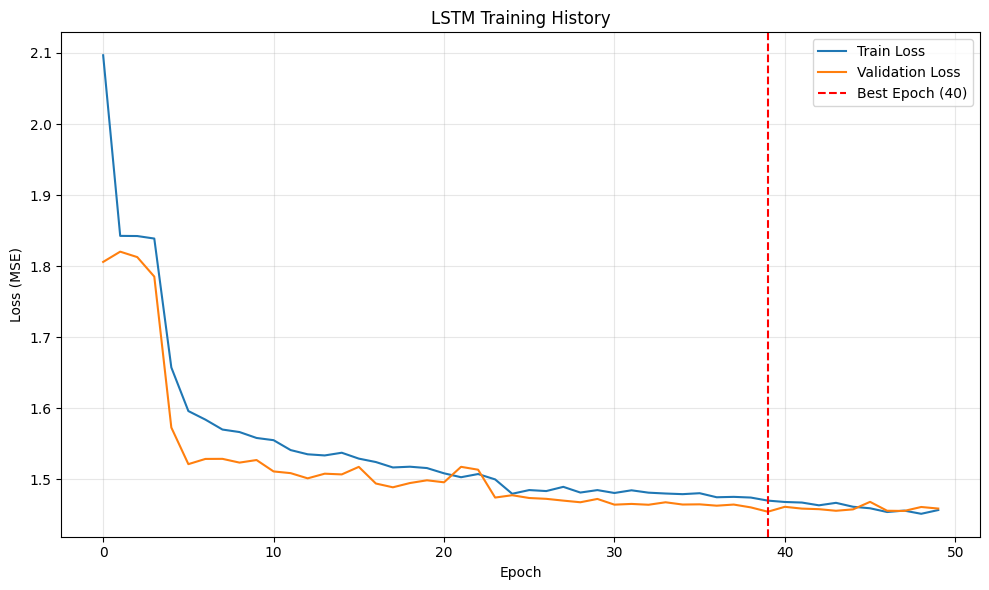

LSTM history plot saved: ..\results\lstm_training_history.png


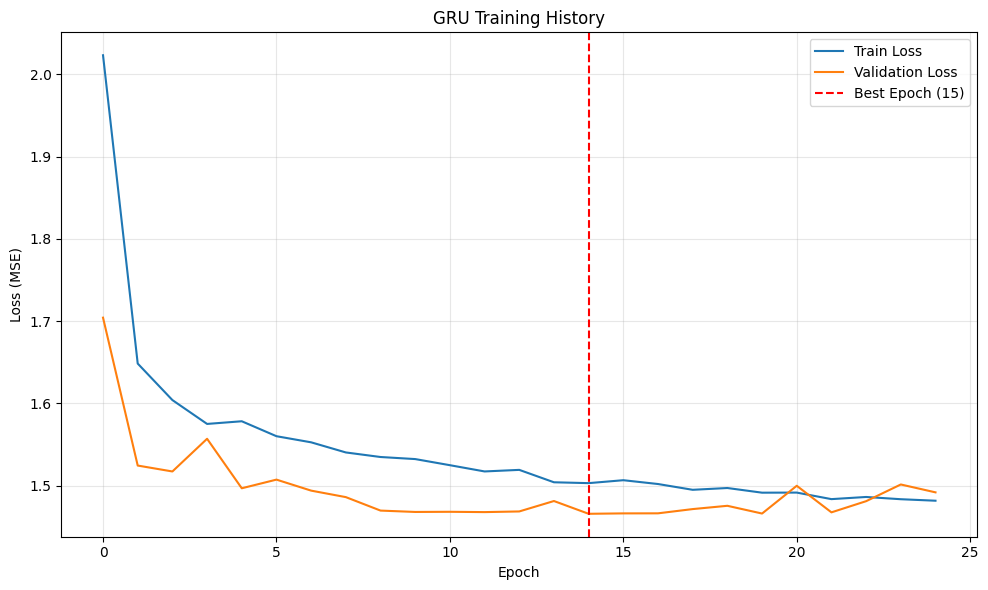

GRU history plot saved: ..\results\gru_training_history.png

STEP 17 complete: Full LSTM and GRU training done, best models loaded, history plots saved.


In [27]:
# STEP 17 — LSTM and GRU with Keras (test run first, then full training)

import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print('Seeds set: random=42, numpy=42, tensorflow=42')

# Ensure sequence inputs are numpy arrays
X_train_seq_np = np.asarray(X_train_seq)
X_val_seq_np = np.asarray(X_val_seq)
X_test_seq_np = np.asarray(X_test_seq)

y_train_seq_np = np.asarray(y_train_seq)
y_val_seq_np = np.asarray(y_val_seq)
y_test_seq_np = np.asarray(y_test_seq)

print('Sequence arrays prepared:')
print(f'X_train_seq: {X_train_seq_np.shape}, y_train_seq: {y_train_seq_np.shape}')
print(f'X_val_seq:   {X_val_seq_np.shape}, y_val_seq:   {y_val_seq_np.shape}')
print(f'X_test_seq:  {X_test_seq_np.shape}, y_test_seq:  {y_test_seq_np.shape}')

input_shape = (5, 248)


def build_lstm_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(128, return_sequences=True),
        Dropout(0.2),
        LSTM(64, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mean_squared_error',
        metrics=['mean_absolute_error']
    )
    return model


def build_gru_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        GRU(128, return_sequences=True),
        Dropout(0.2),
        GRU(64, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mean_squared_error',
        metrics=['mean_absolute_error']
    )
    return model


def build_lstm_test_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(16, return_sequences=True),
        Dropout(0.2),
        LSTM(8, return_sequences=False),
        Dropout(0.2),
        Dense(8, activation='relu'),
        Dense(1)
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mean_squared_error',
        metrics=['mean_absolute_error']
    )
    return model


def build_gru_test_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        GRU(16, return_sequences=True),
        Dropout(0.2),
        GRU(8, return_sequences=False),
        Dropout(0.2),
        Dense(8, activation='relu'),
        Dense(1)
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mean_squared_error',
        metrics=['mean_absolute_error']
    )
    return model


print('\n=== TEST VERSION (small and fast) ===')
X_train_test = X_train_seq_np[:1000]
y_train_test = y_train_seq_np[:1000]
X_val_test = X_val_seq_np[:200]
y_val_test = y_val_seq_np[:200]

print(f'Test train subset: {X_train_test.shape}, {y_train_test.shape}')
print(f'Test val subset:   {X_val_test.shape}, {y_val_test.shape}')

# LSTM test model
lstm_test_model = build_lstm_test_model(input_shape)
print('\nTraining LSTM test version...')
lstm_test_history = lstm_test_model.fit(
    X_train_test, y_train_test,
    validation_data=(X_val_test, y_val_test),
    epochs=3,
    batch_size=256,
    verbose=1
)

# GRU test model
gru_test_model = build_gru_test_model(input_shape)
print('\nTraining GRU test version...')
gru_test_history = gru_test_model.fit(
    X_train_test, y_train_test,
    validation_data=(X_val_test, y_val_test),
    epochs=3,
    batch_size=256,
    verbose=1
)

print('\nTest versions completed successfully and full training is starting.')

# Full models and callbacks
lstm_ckpt_path = 'lstm_best_model.keras'
gru_ckpt_path = 'gru_best_model.keras'

lstm_callbacks = [
    ModelCheckpoint(
        filepath=lstm_ckpt_path,
        monitor='val_loss',
        save_best_only=True,
        mode='min',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-5,
        verbose=1
    )
]

gru_callbacks = [
    ModelCheckpoint(
        filepath=gru_ckpt_path,
        monitor='val_loss',
        save_best_only=True,
        mode='min',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-5,
        verbose=1
    )
]

print('\n=== FULL LSTM MODEL ===')
lstm_model = build_lstm_model(input_shape)
lstm_model.summary()

lstm_history = lstm_model.fit(
    X_train_seq_np, y_train_seq_np,
    validation_data=(X_val_seq_np, y_val_seq_np),
    epochs=100,
    batch_size=64,
    verbose=1,
    callbacks=lstm_callbacks
)

lstm_best_epoch = int(np.argmin(lstm_history.history['val_loss']) + 1)
print(f'LSTM full training finished. Best val_loss epoch: {lstm_best_epoch}')

lstm_best_model = load_model(lstm_ckpt_path)
print(f'LSTM best model loaded from: {lstm_ckpt_path}')

print('\n=== FULL GRU MODEL ===')
gru_model = build_gru_model(input_shape)
gru_model.summary()

gru_history = gru_model.fit(
    X_train_seq_np, y_train_seq_np,
    validation_data=(X_val_seq_np, y_val_seq_np),
    epochs=100,
    batch_size=64,
    verbose=1,
    callbacks=gru_callbacks
)

gru_best_epoch = int(np.argmin(gru_history.history['val_loss']) + 1)
print(f'GRU full training finished. Best val_loss epoch: {gru_best_epoch}')

gru_best_model = load_model(gru_ckpt_path)
print(f'GRU best model loaded from: {gru_ckpt_path}')

# Save history plots
results_dir = os.path.join('..', 'results')
os.makedirs(results_dir, exist_ok=True)

plt.figure(figsize=(10, 6))
plt.plot(lstm_history.history['loss'], label='Train Loss')
plt.plot(lstm_history.history['val_loss'], label='Validation Loss')
plt.axvline(x=lstm_best_epoch - 1, color='red', linestyle='--', label=f'Best Epoch ({lstm_best_epoch})')
plt.title('LSTM Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
lstm_history_plot_path = os.path.join(results_dir, 'lstm_training_history.png')
plt.savefig(lstm_history_plot_path, dpi=150)
plt.show()
print(f'LSTM history plot saved: {lstm_history_plot_path}')

plt.figure(figsize=(10, 6))
plt.plot(gru_history.history['loss'], label='Train Loss')
plt.plot(gru_history.history['val_loss'], label='Validation Loss')
plt.axvline(x=gru_best_epoch - 1, color='red', linestyle='--', label=f'Best Epoch ({gru_best_epoch})')
plt.title('GRU Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
gru_history_plot_path = os.path.join(results_dir, 'gru_training_history.png')
plt.savefig(gru_history_plot_path, dpi=150)
plt.show()
print(f'GRU history plot saved: {gru_history_plot_path}')

print('\nSTEP 17 complete: Full LSTM and GRU training done, best models loaded, history plots saved.')

Test metrics on original receiving_yards scale:
Model     MAE    RMSE     R2
 LSTM 22.1360 32.5977 0.0410
  GRU 22.1725 32.6471 0.0381


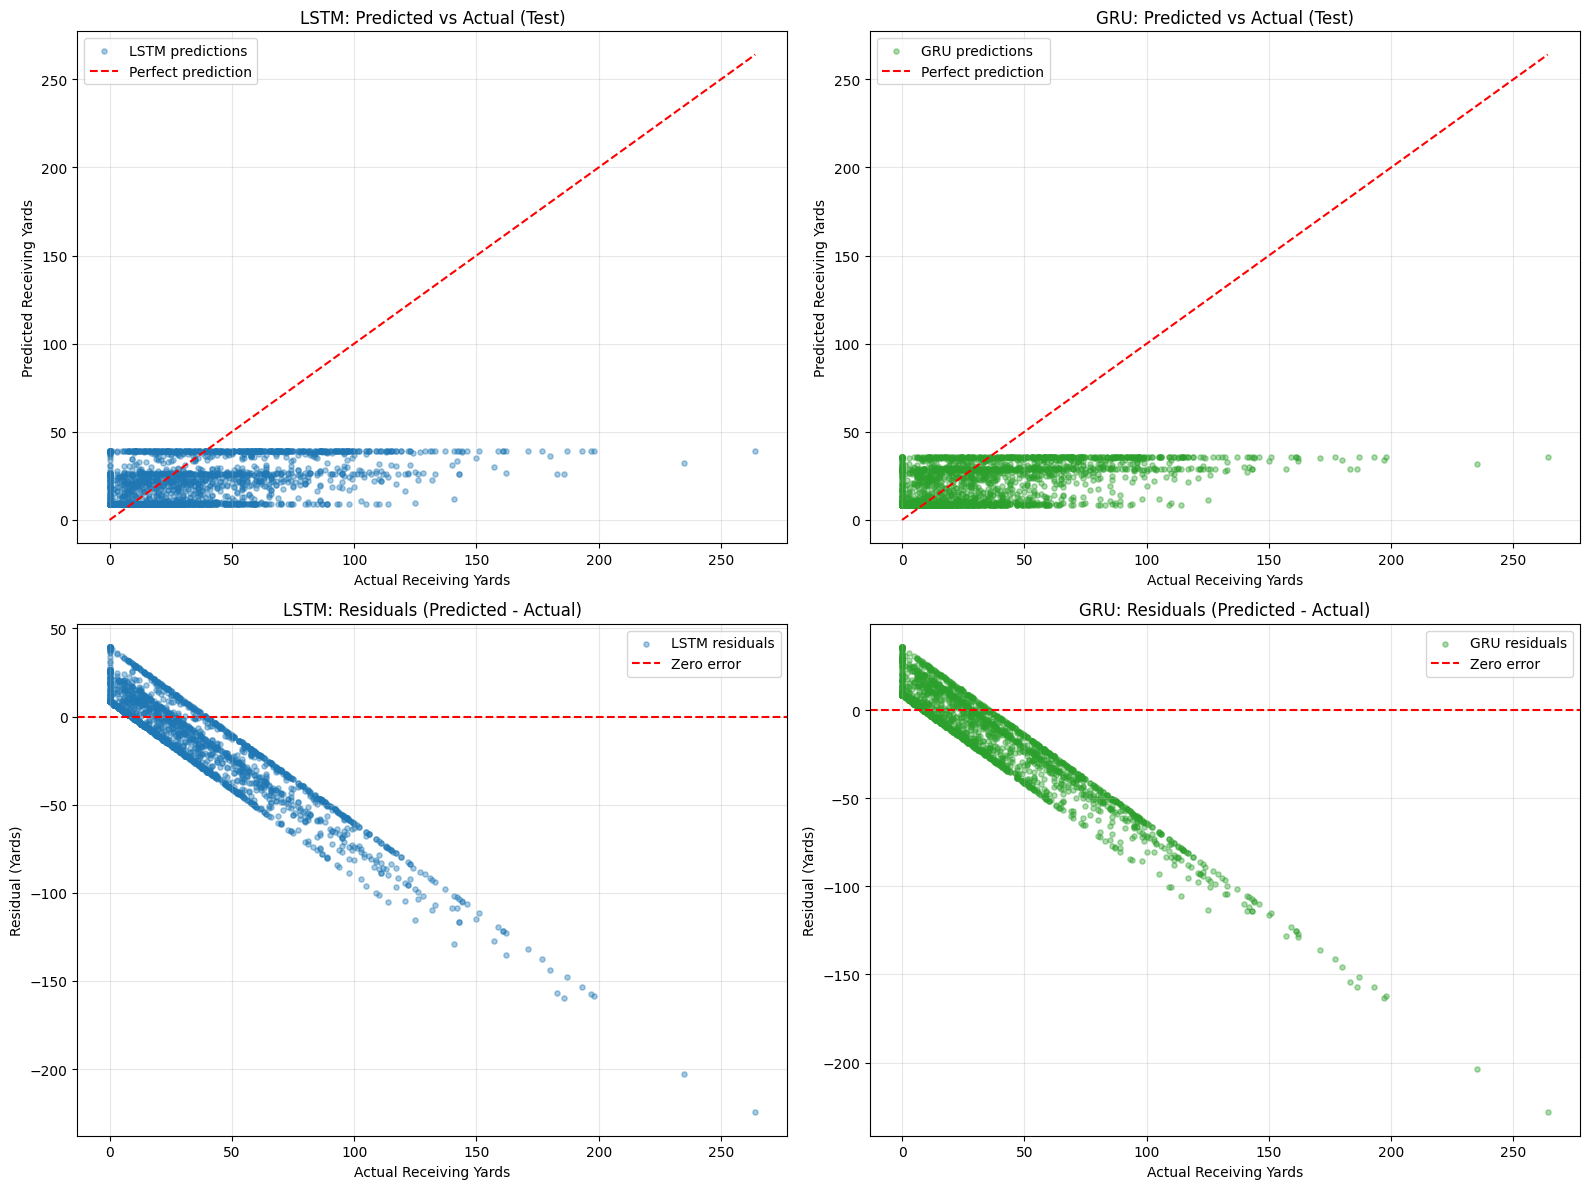

Diagnostics plot saved: ..\results\lstm_gru_test_diagnostics.png
STEP 18 complete: LSTM/GRU evaluation finished.


In [28]:
# STEP 18 — Evaluate best LSTM and GRU on test sequences

import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predictions (log scale)
lstm_pred_log = lstm_best_model.predict(X_test_seq_np, verbose=0).ravel()
gru_pred_log = gru_best_model.predict(X_test_seq_np, verbose=0).ravel()

# Convert to original receiving_yards scale
y_test_orig = np.expm1(y_test_seq_np)
lstm_pred_orig = np.expm1(lstm_pred_log)
gru_pred_orig = np.expm1(gru_pred_log)

# Metrics on original scale
lstm_mae = mean_absolute_error(y_test_orig, lstm_pred_orig)
lstm_rmse = np.sqrt(mean_squared_error(y_test_orig, lstm_pred_orig))
lstm_r2 = r2_score(y_test_orig, lstm_pred_orig)

gru_mae = mean_absolute_error(y_test_orig, gru_pred_orig)
gru_rmse = np.sqrt(mean_squared_error(y_test_orig, gru_pred_orig))
gru_r2 = r2_score(y_test_orig, gru_pred_orig)

comparison_df = pd.DataFrame({
    'Model': ['LSTM', 'GRU'],
    'MAE': [lstm_mae, gru_mae],
    'RMSE': [lstm_rmse, gru_rmse],
    'R2': [lstm_r2, gru_r2]
})

print('Test metrics on original receiving_yards scale:')
print(comparison_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# 2x2 diagnostic plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Axis limits for diagonal reference lines
all_actual = y_test_orig
min_val = float(np.min(all_actual))
max_val = float(np.max(all_actual))

# Top-left: LSTM predicted vs actual
axes[0, 0].scatter(y_test_orig, lstm_pred_orig, alpha=0.4, s=14, label='LSTM predictions')
axes[0, 0].plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect prediction')
axes[0, 0].set_title('LSTM: Predicted vs Actual (Test)')
axes[0, 0].set_xlabel('Actual Receiving Yards')
axes[0, 0].set_ylabel('Predicted Receiving Yards')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Top-right: GRU predicted vs actual
axes[0, 1].scatter(y_test_orig, gru_pred_orig, alpha=0.4, s=14, label='GRU predictions', color='tab:green')
axes[0, 1].plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect prediction')
axes[0, 1].set_title('GRU: Predicted vs Actual (Test)')
axes[0, 1].set_xlabel('Actual Receiving Yards')
axes[0, 1].set_ylabel('Predicted Receiving Yards')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Bottom-left: LSTM residuals
lstm_residuals = lstm_pred_orig - y_test_orig
axes[1, 0].scatter(y_test_orig, lstm_residuals, alpha=0.4, s=14, label='LSTM residuals')
axes[1, 0].axhline(y=0, color='r', linestyle='--', label='Zero error')
axes[1, 0].set_title('LSTM: Residuals (Predicted - Actual)')
axes[1, 0].set_xlabel('Actual Receiving Yards')
axes[1, 0].set_ylabel('Residual (Yards)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Bottom-right: GRU residuals
gru_residuals = gru_pred_orig - y_test_orig
axes[1, 1].scatter(y_test_orig, gru_residuals, alpha=0.4, s=14, label='GRU residuals', color='tab:green')
axes[1, 1].axhline(y=0, color='r', linestyle='--', label='Zero error')
axes[1, 1].set_title('GRU: Residuals (Predicted - Actual)')
axes[1, 1].set_xlabel('Actual Receiving Yards')
axes[1, 1].set_ylabel('Residual (Yards)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()

diagnostics_plot_path = os.path.join('..', 'results', 'lstm_gru_test_diagnostics.png')
plt.savefig(diagnostics_plot_path, dpi=150)
plt.show()

print(f'Diagnostics plot saved: {diagnostics_plot_path}')
print('STEP 18 complete: LSTM/GRU evaluation finished.')

In [29]:
# STEP 19 — Feature selection (priority) with Random Forest + sequence rebuild

from sklearn.ensemble import RandomForestRegressor

# Reproducibility for feature selection
np.random.seed(42)

# Ensure flat scaled features are DataFrames with column names
if isinstance(X_train_scaled, pd.DataFrame):
    X_train_flat_df = X_train_scaled.copy()
    X_val_flat_df = X_val_scaled.copy()
    X_test_flat_df = X_test_scaled.copy()
else:
    X_train_flat_df = pd.DataFrame(X_train_scaled, columns=feature_columns)
    X_val_flat_df = pd.DataFrame(X_val_scaled, columns=feature_columns)
    X_test_flat_df = pd.DataFrame(X_test_scaled, columns=feature_columns)

print('Running RandomForest feature importance on flat training data...')
print(f'Input shape for RF: {X_train_flat_df.shape}')

rf_selector = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    max_depth=None,
    min_samples_leaf=2
)
rf_selector.fit(X_train_flat_df, y_train)

importance_series = pd.Series(rf_selector.feature_importances_, index=X_train_flat_df.columns)
importance_series = importance_series.sort_values(ascending=False)

TOP_N_FEATURES = 25  # target range requested: 20-30
selected_features = importance_series.head(TOP_N_FEATURES).index.tolist()

print(f'\nTop {TOP_N_FEATURES} selected features:')
for i, (fname, fimp) in enumerate(importance_series.head(TOP_N_FEATURES).items(), 1):
    print(f'{i:2d}. {fname:<45} importance={fimp:.6f}')

# Reduced flat sets (optional for tabular models)
X_train_selected = X_train_flat_df[selected_features].copy()
X_val_selected = X_val_flat_df[selected_features].copy()
X_test_selected = X_test_flat_df[selected_features].copy()

print('\nReduced flat feature shapes:')
print(f'X_train_selected: {X_train_selected.shape}')
print(f'X_val_selected:   {X_val_selected.shape}')
print(f'X_test_selected:  {X_test_selected.shape}')

# Rebuild sequence data using ONLY selected features
X_train_seq_selected, y_train_seq_selected, train_idx_selected = build_sequences(
    X_train_selected, y_train, train_df, sequence_length=5
)
X_val_seq_selected, y_val_seq_selected, val_idx_selected = build_sequences(
    X_val_selected, y_val, val_df, sequence_length=5
)
X_test_seq_selected, y_test_seq_selected, test_idx_selected = build_sequences(
    X_test_selected, y_test, test_df, sequence_length=5
)

# Convert to numpy arrays for Keras
X_train_seq_selected_np = np.asarray(X_train_seq_selected)
X_val_seq_selected_np = np.asarray(X_val_seq_selected)
X_test_seq_selected_np = np.asarray(X_test_seq_selected)

y_train_seq_selected_np = np.asarray(y_train_seq_selected)
y_val_seq_selected_np = np.asarray(y_val_seq_selected)
y_test_seq_selected_np = np.asarray(y_test_seq_selected)

print('\nSelected-feature sequence shapes:')
print(f'X_train_seq_selected: {X_train_seq_selected_np.shape}')
print(f'X_val_seq_selected:   {X_val_seq_selected_np.shape}')
print(f'X_test_seq_selected:  {X_test_seq_selected_np.shape}')

print('\nSelected-feature target shapes:')
print(f'y_train_seq_selected: {y_train_seq_selected_np.shape}')
print(f'y_val_seq_selected:   {y_val_seq_selected_np.shape}')
print(f'y_test_seq_selected:  {y_test_seq_selected_np.shape}')

# Quality checks
print('\nQuality checks for selected-feature sequences:')
print('NaN counts:', {
    'train_X': int(np.isnan(X_train_seq_selected_np).sum()),
    'val_X': int(np.isnan(X_val_seq_selected_np).sum()),
    'test_X': int(np.isnan(X_test_seq_selected_np).sum())
})
print('Inf counts:', {
    'train_X': int(np.isinf(X_train_seq_selected_np).sum()),
    'val_X': int(np.isinf(X_val_seq_selected_np).sum()),
    'test_X': int(np.isinf(X_test_seq_selected_np).sum())
})

# Save importance report
os.makedirs(os.path.join('..', 'results'), exist_ok=True)
importance_path = os.path.join('..', 'results', 'rf_feature_importance_top25.csv')
importance_series.head(TOP_N_FEATURES).rename('importance').to_csv(importance_path)
print(f'\nSaved top feature importance report: {importance_path}')
print('STEP 19 complete: top features selected and sequences regenerated.')

Running RandomForest feature importance on flat training data...
Input shape for RF: (25147, 248)

Top 25 selected features:
 1. targets_roll5                                 importance=0.149462
 2. target_share_std_roll5                        importance=0.028417
 3. first_downs_roll5                             importance=0.023307
 4. target_share_std_roll3                        importance=0.021086
 5. target_share_std_lag1                         importance=0.011379
 6. career_avg_yards_last_season                  importance=0.009590
 7. pregame_total                                 importance=0.008023
 8. target_share_roll5                            importance=0.007913
 9. avg_start_yardline_lag1                       importance=0.007866
10. team_epa_lag1                                 importance=0.007504
11. pregame_spread                                importance=0.007456
12. air_yards_roll5                               importance=0.007174
13. qb_air_yards_lag1              

Enhanced model input shape: (5, 25)

=== LSTM BN+LARGE (top25 features) ===


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 5, 256)         │       288,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 5, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 5, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 128)            │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 497,793 (1.90 MB)

 Trainable params: 497,025 (1.90 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_4 (GRU)                     │ (None, 5, 256)         │       217,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 5, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 5, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_5 (GRU)                     │ (None, 128)            │       148,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 377,473 (1.44 MB)

 Trainable params: 376,705 (1.44 MB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/100
209/216 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.6393 - mean_absolute_error: 1.2435
Epoch 1: val_loss improved from None to 1.66578, saving model to gru_bn_large_top25_best.keras

Epoch 1: finished saving model to gru_bn_large_top25_best.keras
216/216 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 1.8795 - mean_absolute_error: 1.0577 - val_loss: 1.6658 - val_mean_absolute_error: 1.0809 - learning_rate: 0.0010
Epoch 2/100
211/216 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.5608 - mean_absolute_error: 0.9667
Epoch 2: val_loss improved from 1.66578 to 1.47061, saving model to gru_bn_large_top25_best.keras

Epoch 2: finished saving model to gru_bn_large_top25_best.keras
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 1.5381 - mean_absolute_error: 0.9582 - val_loss: 1.4706 - val_mean_absolute_error: 0.9664 - learning_rate: 0.0010
Epoch 3/100
212/216 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.5042 - mean_absolute_error: 0.9427
Epoch 3: val_loss improved from 1.47061 to 1.44709, savin

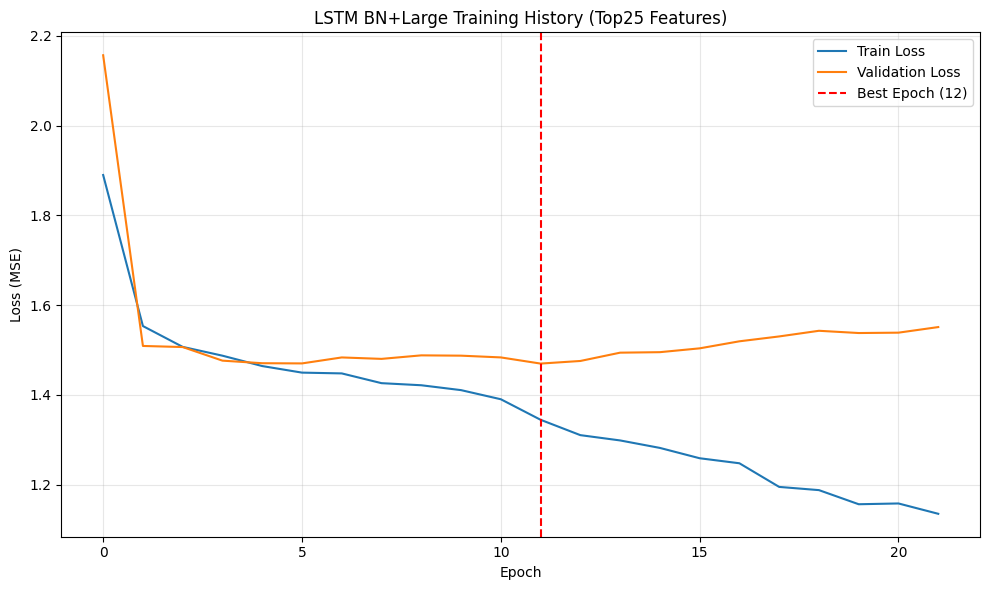

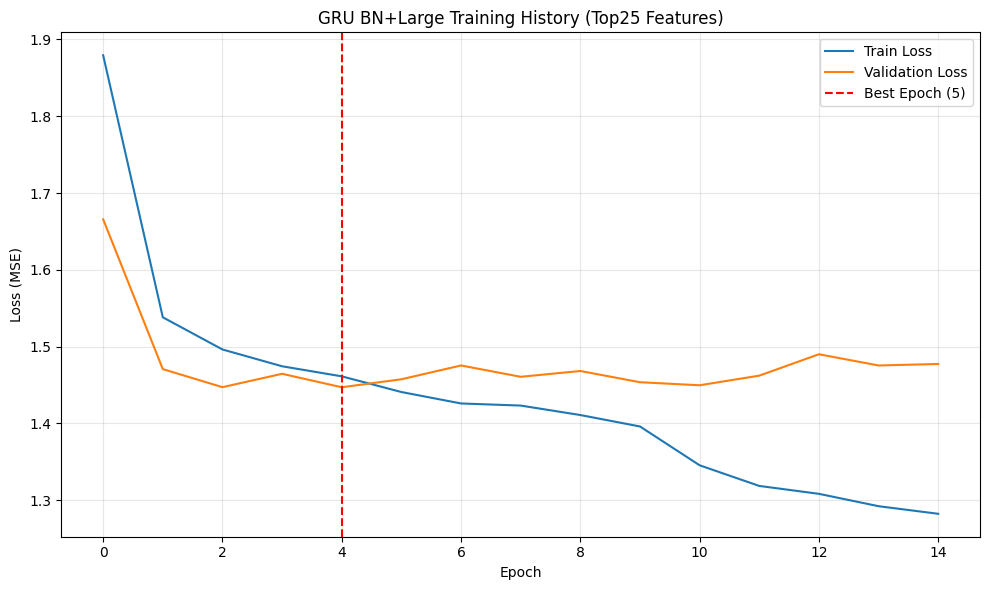

Saved: ..\results\lstm_bn_large_top25_history.png
Saved: ..\results\gru_bn_large_top25_history.png
STEP 20 complete: BatchNorm + larger architecture trained and evaluated.


In [30]:
# STEP 20 — Enhanced architecture with BatchNormalization and larger capacity (selected 25 features)

from tensorflow.keras.layers import BatchNormalization

# Reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

selected_input_shape = (X_train_seq_selected_np.shape[1], X_train_seq_selected_np.shape[2])
print(f'Enhanced model input shape: {selected_input_shape}')


def build_lstm_model_bn_large(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(256, return_sequences=True),
        BatchNormalization(),
        Dropout(0.3),
        LSTM(128, return_sequences=False),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mean_squared_error',
        metrics=['mean_absolute_error']
    )
    return model


def build_gru_model_bn_large(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        GRU(256, return_sequences=True),
        BatchNormalization(),
        Dropout(0.3),
        GRU(128, return_sequences=False),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mean_squared_error',
        metrics=['mean_absolute_error']
    )
    return model


# Callbacks
lstm_bn_ckpt = 'lstm_bn_large_top25_best.keras'
gru_bn_ckpt = 'gru_bn_large_top25_best.keras'

lstm_bn_callbacks = [
    ModelCheckpoint(lstm_bn_ckpt, monitor='val_loss', save_best_only=True, mode='min', verbose=1),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=1),
]

gru_bn_callbacks = [
    ModelCheckpoint(gru_bn_ckpt, monitor='val_loss', save_best_only=True, mode='min', verbose=1),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=1),
]

print('\n=== LSTM BN+LARGE (top25 features) ===')
lstm_bn_large = build_lstm_model_bn_large(selected_input_shape)
lstm_bn_large.summary()

lstm_bn_history = lstm_bn_large.fit(
    X_train_seq_selected_np,
    y_train_seq_selected_np,
    validation_data=(X_val_seq_selected_np, y_val_seq_selected_np),
    epochs=100,
    batch_size=64,
    verbose=1,
    callbacks=lstm_bn_callbacks,
)

lstm_bn_best_epoch = int(np.argmin(lstm_bn_history.history['val_loss']) + 1)
print(f'LSTM BN+LARGE training finished. Best val_loss epoch: {lstm_bn_best_epoch}')

lstm_bn_best_model = load_model(lstm_bn_ckpt)
print(f'Loaded best LSTM BN+LARGE model from: {lstm_bn_ckpt}')

print('\n=== GRU BN+LARGE (top25 features) ===')
gru_bn_large = build_gru_model_bn_large(selected_input_shape)
gru_bn_large.summary()

gru_bn_history = gru_bn_large.fit(
    X_train_seq_selected_np,
    y_train_seq_selected_np,
    validation_data=(X_val_seq_selected_np, y_val_seq_selected_np),
    epochs=100,
    batch_size=64,
    verbose=1,
    callbacks=gru_bn_callbacks,
)

gru_bn_best_epoch = int(np.argmin(gru_bn_history.history['val_loss']) + 1)
print(f'GRU BN+LARGE training finished. Best val_loss epoch: {gru_bn_best_epoch}')

gru_bn_best_model = load_model(gru_bn_ckpt)
print(f'Loaded best GRU BN+LARGE model from: {gru_bn_ckpt}')

# Evaluate on test (original scale)
lstm_bn_pred_log = lstm_bn_best_model.predict(X_test_seq_selected_np, verbose=0).ravel()
gru_bn_pred_log = gru_bn_best_model.predict(X_test_seq_selected_np, verbose=0).ravel()

y_test_selected_orig = np.expm1(y_test_seq_selected_np)
lstm_bn_pred_orig = np.expm1(lstm_bn_pred_log)
gru_bn_pred_orig = np.expm1(gru_bn_pred_log)

lstm_bn_mae = mean_absolute_error(y_test_selected_orig, lstm_bn_pred_orig)
lstm_bn_rmse = np.sqrt(mean_squared_error(y_test_selected_orig, lstm_bn_pred_orig))
lstm_bn_r2 = r2_score(y_test_selected_orig, lstm_bn_pred_orig)

gru_bn_mae = mean_absolute_error(y_test_selected_orig, gru_bn_pred_orig)
gru_bn_rmse = np.sqrt(mean_squared_error(y_test_selected_orig, gru_bn_pred_orig))
gru_bn_r2 = r2_score(y_test_selected_orig, gru_bn_pred_orig)

comparison_bn = pd.DataFrame({
    'Model': ['LSTM_BN_LARGE_TOP25', 'GRU_BN_LARGE_TOP25'],
    'MAE': [lstm_bn_mae, gru_bn_mae],
    'RMSE': [lstm_bn_rmse, gru_bn_rmse],
    'R2': [lstm_bn_r2, gru_bn_r2],
})

print('\nEnhanced architecture test metrics (original yards scale):')
print(comparison_bn.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# Save history plots
results_dir = os.path.join('..', 'results')
os.makedirs(results_dir, exist_ok=True)

plt.figure(figsize=(10, 6))
plt.plot(lstm_bn_history.history['loss'], label='Train Loss')
plt.plot(lstm_bn_history.history['val_loss'], label='Validation Loss')
plt.axvline(x=lstm_bn_best_epoch - 1, color='red', linestyle='--', label=f'Best Epoch ({lstm_bn_best_epoch})')
plt.title('LSTM BN+Large Training History (Top25 Features)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
lstm_bn_hist_path = os.path.join(results_dir, 'lstm_bn_large_top25_history.png')
plt.savefig(lstm_bn_hist_path, dpi=150)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(gru_bn_history.history['loss'], label='Train Loss')
plt.plot(gru_bn_history.history['val_loss'], label='Validation Loss')
plt.axvline(x=gru_bn_best_epoch - 1, color='red', linestyle='--', label=f'Best Epoch ({gru_bn_best_epoch})')
plt.title('GRU BN+Large Training History (Top25 Features)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
gru_bn_hist_path = os.path.join(results_dir, 'gru_bn_large_top25_history.png')
plt.savefig(gru_bn_hist_path, dpi=150)
plt.show()

print(f'Saved: {lstm_bn_hist_path}')
print(f'Saved: {gru_bn_hist_path}')
print('STEP 20 complete: BatchNorm + larger architecture trained and evaluated.')

In [31]:
# STEP 20b — Compact metric comparison: previous vs BN+Large(top25)

comparison_all = pd.DataFrame([
    {'Model': 'LSTM (old, 248f)', 'MAE': lstm_mae, 'RMSE': lstm_rmse, 'R2': lstm_r2},
    {'Model': 'GRU (old, 248f)', 'MAE': gru_mae, 'RMSE': gru_rmse, 'R2': gru_r2},
    {'Model': 'LSTM BN+Large (top25)', 'MAE': lstm_bn_mae, 'RMSE': lstm_bn_rmse, 'R2': lstm_bn_r2},
    {'Model': 'GRU BN+Large (top25)', 'MAE': gru_bn_mae, 'RMSE': gru_bn_rmse, 'R2': gru_bn_r2},
])

print('Metric comparison on test set (original receiving_yards scale):')
print(comparison_all.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

best_mae_model = comparison_all.loc[comparison_all['MAE'].idxmin(), 'Model']
best_rmse_model = comparison_all.loc[comparison_all['RMSE'].idxmin(), 'Model']
best_r2_model = comparison_all.loc[comparison_all['R2'].idxmax(), 'Model']

print('\nBest by MAE :', best_mae_model)
print('Best by RMSE:', best_rmse_model)
print('Best by R2  :', best_r2_model)

Metric comparison on test set (original receiving_yards scale):
                Model     MAE    RMSE      R2
     LSTM (old, 248f) 22.1360 32.5977  0.0410
      GRU (old, 248f) 22.1725 32.6471  0.0381
LSTM BN+Large (top25) 22.4319 33.5132 -0.0136
 GRU BN+Large (top25) 22.7112 33.8326 -0.0330

Best by MAE : LSTM (old, 248f)
Best by RMSE: LSTM (old, 248f)
Best by R2  : LSTM (old, 248f)


In [32]:
# STEP 21 — Baseline control experiments on ORIGINAL 248 features
# 1) keep baseline
# 2) Huber only
# 3) sample weights only
# 4) Huber + sample weights

import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Input, LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Allow running after Step 16 even if Step 17 was not rerun
if 'X_train_seq_np' not in globals() and 'X_train_seq' in globals():
    X_train_seq_np = np.asarray(X_train_seq)
if 'X_val_seq_np' not in globals() and 'X_val_seq' in globals():
    X_val_seq_np = np.asarray(X_val_seq)
if 'X_test_seq_np' not in globals() and 'X_test_seq' in globals():
    X_test_seq_np = np.asarray(X_test_seq)

if 'y_train_seq_np' not in globals() and 'y_train_seq' in globals():
    y_train_seq_np = np.asarray(y_train_seq)
if 'y_val_seq_np' not in globals() and 'y_val_seq' in globals():
    y_val_seq_np = np.asarray(y_val_seq)
if 'y_test_seq_np' not in globals() and 'y_test_seq' in globals():
    y_test_seq_np = np.asarray(y_test_seq)

required_vars = ['X_train_seq_np', 'X_val_seq_np', 'X_test_seq_np', 'y_train_seq_np', 'y_val_seq_np', 'y_test_seq_np']
missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise RuntimeError(
        'Missing sequence variables in memory: ' + str(missing_vars) +
        '. Run the sequence + baseline training cells first (Step 16/17/18), then rerun this cell.'
    )

print('Running Step 21 on ORIGINAL 248-feature sequence arrays:')
print(f'X_train_seq_np: {X_train_seq_np.shape}')
print(f'X_val_seq_np:   {X_val_seq_np.shape}')
print(f'X_test_seq_np:  {X_test_seq_np.shape}')


def build_lstm_baseline_248(loss_fn='mean_squared_error'):
    # Exact baseline architecture (same as original best model)
    model = Sequential([
        Input(shape=(5, 248)),
        LSTM(128, return_sequences=True),
        Dropout(0.2),
        LSTM(64, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss=loss_fn,
        metrics=['mean_absolute_error']
    )
    return model


def evaluate_model_on_test(model):
    pred_log = model.predict(X_test_seq_np, verbose=0).ravel()
    y_true = np.expm1(y_test_seq_np)
    y_pred = np.expm1(pred_log)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2


def run_variant(name, loss_fn, sample_weight=None):
    ckpt_path = f'{name}.keras'

    callbacks = [
        ModelCheckpoint(ckpt_path, monitor='val_loss', save_best_only=True, mode='min', verbose=1),
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=1),
    ]

    model = build_lstm_baseline_248(loss_fn=loss_fn)

    fit_kwargs = dict(
        x=X_train_seq_np,
        y=y_train_seq_np,
        validation_data=(X_val_seq_np, y_val_seq_np),
        epochs=100,
        batch_size=64,
        verbose=1,
        callbacks=callbacks,
    )
    if sample_weight is not None:
        fit_kwargs['sample_weight'] = sample_weight

    print(f'\n=== Training {name} ===')
    history = model.fit(**fit_kwargs)
    best_epoch = int(np.argmin(history.history['val_loss']) + 1)

    best_model = load_model(ckpt_path)
    mae, rmse, r2 = evaluate_model_on_test(best_model)

    print(f'{name} -> MAE={mae:.4f}, RMSE={rmse:.4f}, R2={r2:.4f}, best_epoch={best_epoch}')
    return {
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'BestEpoch': best_epoch,
        'Checkpoint': ckpt_path
    }


# Baseline row (from already trained baseline if available; else from saved checkpoint)
if all(k in globals() for k in ['lstm_mae', 'lstm_rmse', 'lstm_r2', 'lstm_best_epoch']):
    baseline_row = {
        'Model': 'baseline_mse_existing',
        'MAE': float(lstm_mae),
        'RMSE': float(lstm_rmse),
        'R2': float(lstm_r2),
        'BestEpoch': int(lstm_best_epoch),
        'Checkpoint': 'lstm_best_model.keras'
    }
else:
    if not os.path.exists('lstm_best_model.keras'):
        raise RuntimeError('Baseline model not found in memory or on disk (lstm_best_model.keras).')
    baseline_model = load_model('lstm_best_model.keras')
    b_mae, b_rmse, b_r2 = evaluate_model_on_test(baseline_model)
    baseline_row = {
        'Model': 'baseline_mse_loaded',
        'MAE': b_mae,
        'RMSE': b_rmse,
        'R2': b_r2,
        'BestEpoch': np.nan,
        'Checkpoint': 'lstm_best_model.keras'
    }

# Step 3 weights on ORIGINAL yards scale
y_train_seq_original = np.expm1(y_train_seq_np)
weights = np.where(y_train_seq_original > 50, 2.0, 1.0).astype(np.float32)
print('\nSample weights distribution (threshold 50 yards):')
print(pd.Series(weights).value_counts().sort_index())

# Step 2: Huber only (single-line logical change is loss)
huber_row = run_variant(
    name='lstm_248_huber_only',
    loss_fn=tf.keras.losses.Huber(delta=1.0),
    sample_weight=None
)

# Step 3: MSE + sample weights
weights_row = run_variant(
    name='lstm_248_mse_weights50',
    loss_fn='mean_squared_error',
    sample_weight=weights
)

# Step 4: Huber + sample weights
huber_weights_row = run_variant(
    name='lstm_248_huber_weights50',
    loss_fn=tf.keras.losses.Huber(delta=1.0),
    sample_weight=weights
)

step21_results = pd.DataFrame([baseline_row, huber_row, weights_row, huber_weights_row])

print('\n=== STEP 21 COMPARISON (original receiving_yards scale) ===')
print(step21_results[['Model', 'MAE', 'RMSE', 'R2', 'BestEpoch']].to_string(index=False, float_format=lambda x: f'{x:.4f}'))

best_r2_row = step21_results.loc[step21_results['R2'].idxmax()]
print(f"\nBest by R2: {best_r2_row['Model']} (R2={best_r2_row['R2']:.4f})")

os.makedirs(os.path.join('..', 'results'), exist_ok=True)
step21_out = os.path.join('..', 'results', 'step21_huber_weights_on_248.csv')
step21_results.to_csv(step21_out, index=False)
print(f'Results saved: {step21_out}')

Running Step 21 on ORIGINAL 248-feature sequence arrays:
X_train_seq_np: (13817, 5, 248)
X_val_seq_np:   (4360, 5, 248)
X_test_seq_np:  (2331, 5, 248)

Sample weights distribution (threshold 50 yards):
1.0    10387
2.0     3430
Name: count, dtype: int64

=== Training lstm_248_huber_only ===
Epoch 1/100
211/216 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9163 - mean_absolute_error: 1.3281
Epoch 1: val_loss improved from None to 0.65172, saving model to lstm_248_huber_only.keras

Epoch 1: finished saving model to lstm_248_huber_only.keras
216/216 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.7196 - mean_absolute_error: 1.1203 - val_loss: 0.6517 - val_mean_absolute_error: 1.0431 - learning_rate: 0.0010
Epoch 2/100
211/216 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6537 - mean_absolute_error: 1.0465
Epoch 2: val_loss did not improve from 0.65172
216/216 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6530 - mean_absolute_error: 1.0469 - val_loss: 0.6532 - val_mean_absolute_error: 1.0442 - learning_

In [33]:
# STEP 21 summary (compact)
print(step21_results[['Model', 'MAE', 'RMSE', 'R2', 'BestEpoch']].to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print('\nBest by R2:', step21_results.loc[step21_results['R2'].idxmax(), 'Model'])
print('CSV:', step21_out)

                   Model     MAE    RMSE      R2  BestEpoch
   baseline_mse_existing 22.1360 32.5977  0.0410         40
     lstm_248_huber_only 24.5523 35.4424 -0.1337         22
  lstm_248_mse_weights50 21.0140 30.2153  0.1760         30
lstm_248_huber_weights50 24.4764 34.3122 -0.0625         26

Best by R2: lstm_248_mse_weights50
CSV: ..\results\step21_huber_weights_on_248.csv


Trial 30 Complete [00h 00m 16s]
val_loss: 0.40648066997528076

Best val_loss So Far: 0.33862558007240295
Total elapsed time: 00h 15m 27s

Best GRU hyperparameters:
  units_1: 128
  units_2: 64
  dropout_rate: 0.30000000000000004
  learning_rate: 0.0001
  huber_delta: 0.5
Best GRU val_loss: 0.338626
STEP 4 complete.

STEP 5: Final LSTM model summary


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 5, 256)         │       517,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 5, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 5, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 555,809 (2.12 MB)

 Trainable params: 555,233 (2.12 MB)

 Non-trainable params: 576 (2.25 KB)

Epoch 1/100
214/216 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.2669 - mean_absolute_error: 2.7779
Epoch 1: val_loss improved from None to 1.15644, saving model to lstm_final_best.keras

Epoch 1: finished saving model to lstm_final_best.keras
216/216 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 1.1776 - mean_absolute_error: 2.5990 - val_loss: 1.1564 - val_mean_absolute_error: 2.5598 - learning_rate: 1.0000e-04
Epoch 2/100
215/216 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.8555 - mean_absolute_error: 1.9523
Epoch 2: val_loss improved from 1.15644 to 0.41578, saving model to lstm_final_best.keras

Epoch 2: finished saving model to lstm_final_best.keras
216/216 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.7601 - mean_absolute_error: 1.7598 - val_loss: 0.4158 - val_mean_absolute_error: 1.0590 - learning_rate: 1.0000e-04
Epoch 3/100
213/216 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.5507 - mean_absolute_error: 1.3330
Epoch 3: val_loss improved from 0.41578 to 0.35963, saving model to lstm_fin

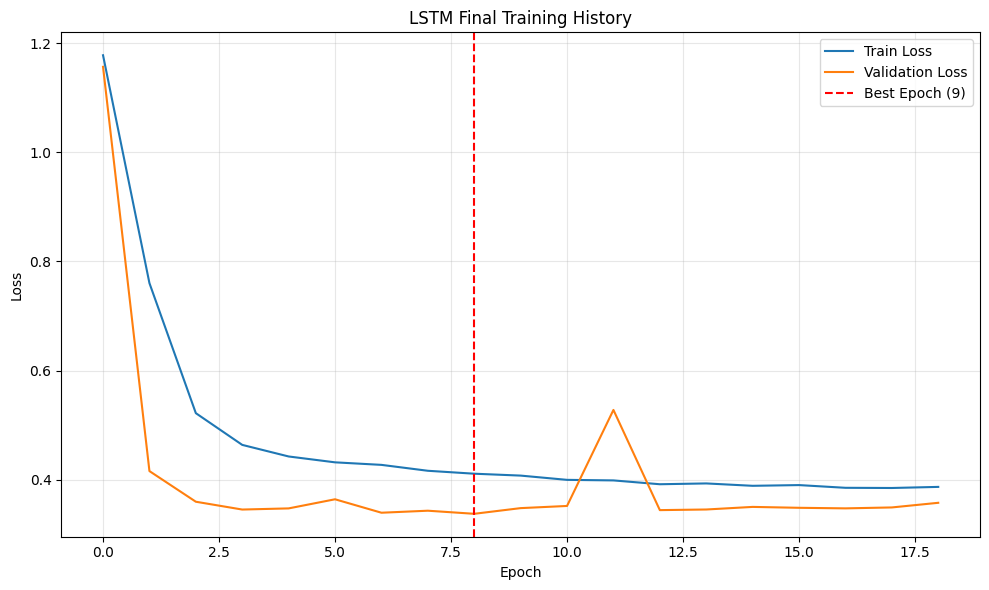

STEP 5 complete.

STEP 6: Final GRU model summary


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 5, 128)         │       145,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 5, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 5, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,281 (723.75 KB)

 Trainable params: 184,897 (722.25 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/100
211/216 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.3777 - mean_absolute_error: 2.9999
Epoch 1: val_loss improved from None to 1.08598, saving model to gru_final_best.keras

Epoch 1: finished saving model to gru_final_best.keras
216/216 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 1.0906 - mean_absolute_error: 2.4231 - val_loss: 1.0860 - val_mean_absolute_error: 2.4207 - learning_rate: 1.0000e-04
Epoch 2/100
211/216 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6632 - mean_absolute_error: 1.5616
Epoch 2: val_loss improved from 1.08598 to 0.59305, saving model to gru_final_best.keras

Epoch 2: finished saving model to gru_final_best.keras
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.6431 - mean_absolute_error: 1.5212 - val_loss: 0.5931 - val_mean_absolute_error: 1.4226 - learning_rate: 1.0000e-04
Epoch 3/100
211/216 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5922 - mean_absolute_error: 1.4177
Epoch 3: val_loss improved from 0.59305 to 0.44843, saving model to gru_final_best.

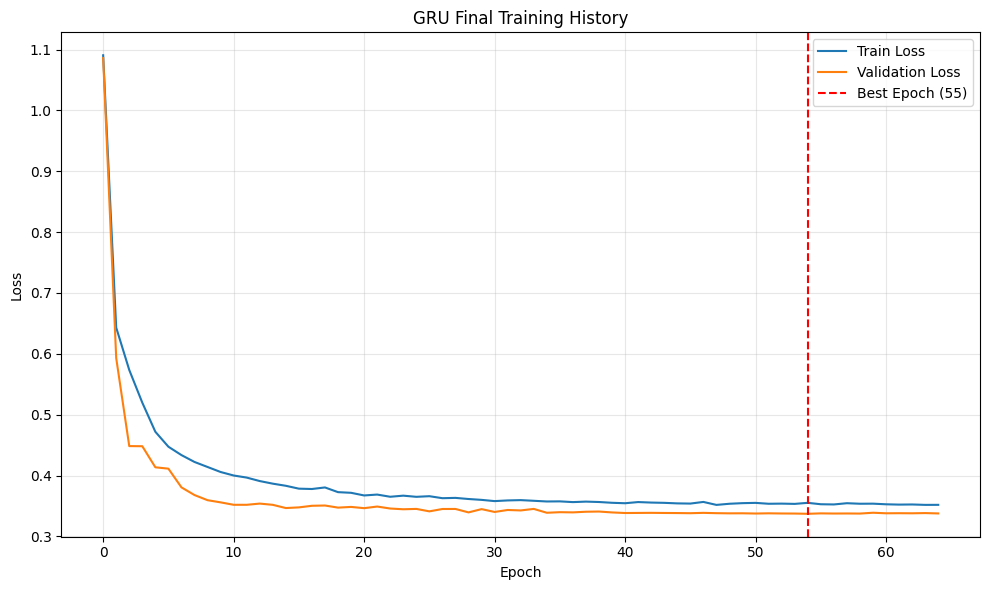

STEP 6 complete.

Final comparison table (original receiving_yards scale):
              Model     MAE    RMSE     R2
       LSTM (tuned) 20.5987 29.8463 0.1961
       GRU  (tuned) 20.7552 29.7766 0.1998
LSTM (baseline MSE) 21.4732 31.4857 0.1053
  LSTM (huber only) 20.5743 29.5129 0.2139
STEP 7 complete.


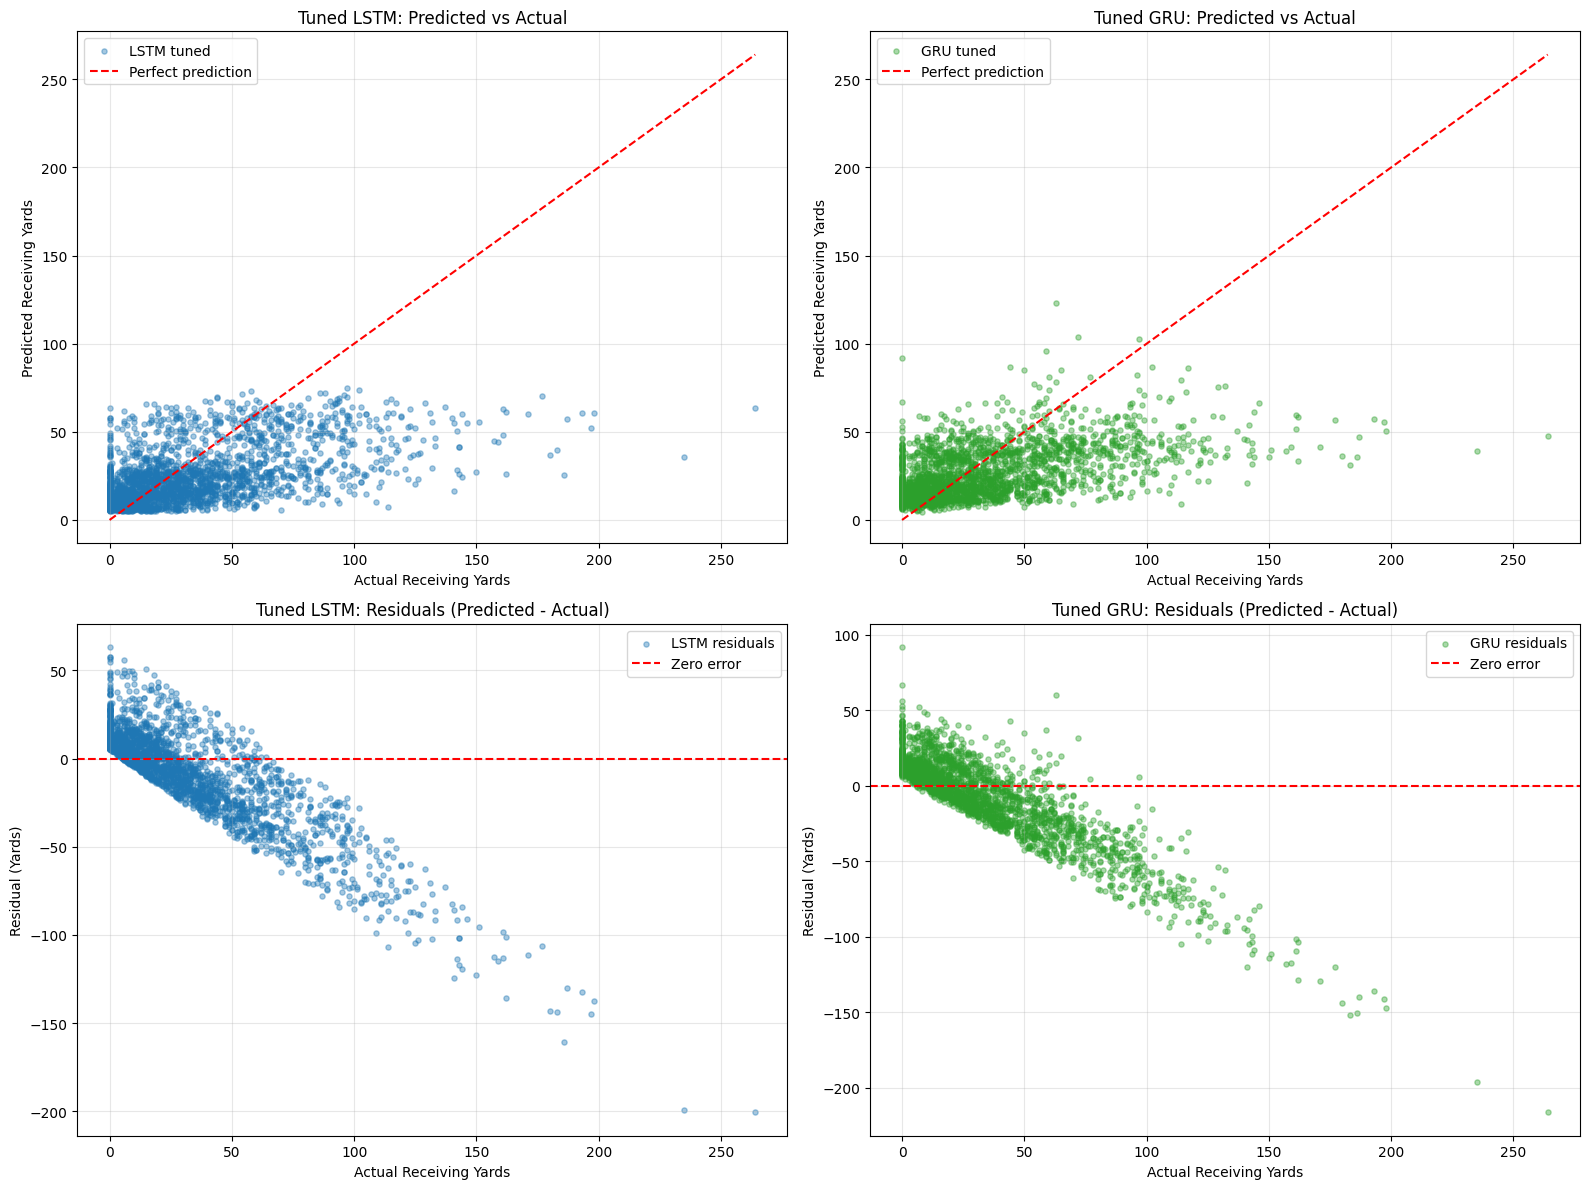

STEP 8 complete. Final plots saved: ..\results\tuned_lstm_gru_final_diagnostics.png
Comparison table saved: ..\results\tuned_lstm_gru_comparison.csv
Saved final tuned models: lstm_tuned_final_saved.keras, gru_tuned_final_saved.keras


In [34]:
# STEP 22 — Keras Tuner Bayesian Optimization (LSTM + GRU), final training, and one-time test evaluation

# STEP 1 — setup
import os
import sys
import random
import subprocess
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

# Install and import keras_tuner
try:
    import keras_tuner as kt
except ImportError:
    print('Installing keras-tuner...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'keras-tuner'])
    import keras_tuner as kt

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Input, LSTM, GRU, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print('STEP 1 complete: setup + seeds + keras_tuner imported.')
print(f'Using existing arrays only: X_train_seq={X_train_seq.shape}, X_val_seq={X_val_seq.shape}, X_test_seq={X_test_seq.shape}')

# STEP 2 — hyperparameter search space
# NOTE: using existing sequence variables; no preprocessing and no redefinition of core arrays.

def build_lstm_model(hp):
    units_1 = hp.Choice('units_1', [64, 128, 256])
    units_2 = hp.Choice('units_2', [32, 64, 128])
    dropout_rate = hp.Float('dropout_rate', min_value=0.1, max_value=0.4, step=0.1)
    learning_rate = hp.Choice('learning_rate', [1e-4, 1e-3, 1e-2])
    huber_delta = hp.Choice('huber_delta', [0.5, 1.0, 2.0, 3.0])

    model = Sequential([
        Input(shape=(5, 248)),
        LSTM(units_1, return_sequences=True),
        BatchNormalization(),
        Dropout(dropout_rate),
        LSTM(units_2, return_sequences=False),
        BatchNormalization(),
        Dropout(dropout_rate),
        Dense(max(units_2 // 2, 1), activation='relu'),
        Dense(1)
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss=tf.keras.losses.Huber(delta=huber_delta),
        metrics=['mean_absolute_error']
    )
    return model


def build_gru_model(hp):
    units_1 = hp.Choice('units_1', [64, 128, 256])
    units_2 = hp.Choice('units_2', [32, 64, 128])
    dropout_rate = hp.Float('dropout_rate', min_value=0.1, max_value=0.4, step=0.1)
    learning_rate = hp.Choice('learning_rate', [1e-4, 1e-3, 1e-2])
    huber_delta = hp.Choice('huber_delta', [0.5, 1.0, 2.0, 3.0])

    model = Sequential([
        Input(shape=(5, 248)),
        GRU(units_1, return_sequences=True),
        BatchNormalization(),
        Dropout(dropout_rate),
        GRU(units_2, return_sequences=False),
        BatchNormalization(),
        Dropout(dropout_rate),
        Dense(max(units_2 // 2, 1), activation='relu'),
        Dense(1)
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss=tf.keras.losses.Huber(delta=huber_delta),
        metrics=['mean_absolute_error']
    )
    return model

print('STEP 2 complete: build_lstm_model(hp) and build_gru_model(hp) defined.')

# STEP 3 — Bayesian Optimization for LSTM
lstm_tuner = kt.BayesianOptimization(
    hypermodel=build_lstm_model,
    objective=kt.Objective('val_loss', direction='min'),
    max_trials=30,
    directory='tuning_lstm',
    project_name='lstm_wr_tuning',
    overwrite=True,
)

lstm_search_callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]

print('\nSTEP 3: Starting LSTM Bayesian search...')
lstm_tuner.search(
    X_train_seq,
    y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=50,
    batch_size=64,
    callbacks=lstm_search_callbacks,
    verbose=1,
)

best_lstm_hp = lstm_tuner.get_best_hyperparameters(num_trials=1)[0]
best_lstm_trial = lstm_tuner.oracle.get_best_trials(num_trials=1)[0]
print('\nBest LSTM hyperparameters:')
for k in ['units_1', 'units_2', 'dropout_rate', 'learning_rate', 'huber_delta']:
    print(f'  {k}: {best_lstm_hp.get(k)}')
print(f"Best LSTM val_loss: {best_lstm_trial.score:.6f}")
print('STEP 3 complete.')

# STEP 4 — Bayesian Optimization for GRU
gru_tuner = kt.BayesianOptimization(
    hypermodel=build_gru_model,
    objective=kt.Objective('val_loss', direction='min'),
    max_trials=30,
    directory='tuning_gru',
    project_name='gru_wr_tuning',
    overwrite=True,
)

gru_search_callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]

print('\nSTEP 4: Starting GRU Bayesian search...')
gru_tuner.search(
    X_train_seq,
    y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=50,
    batch_size=64,
    callbacks=gru_search_callbacks,
    verbose=1,
)

best_gru_hp = gru_tuner.get_best_hyperparameters(num_trials=1)[0]
best_gru_trial = gru_tuner.oracle.get_best_trials(num_trials=1)[0]
print('\nBest GRU hyperparameters:')
for k in ['units_1', 'units_2', 'dropout_rate', 'learning_rate', 'huber_delta']:
    print(f'  {k}: {best_gru_hp.get(k)}')
print(f"Best GRU val_loss: {best_gru_trial.score:.6f}")
print('STEP 4 complete.')

# STEP 5 — final LSTM training
lstm_final_model = build_lstm_model(best_lstm_hp)
print('\nSTEP 5: Final LSTM model summary')
lstm_final_model.summary()

lstm_final_callbacks = [
    ModelCheckpoint('lstm_final_best.keras', monitor='val_loss', save_best_only=True, mode='min', verbose=1),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=1),
]

lstm_final_history = lstm_final_model.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=100,
    batch_size=64,
    verbose=1,
    callbacks=lstm_final_callbacks,
)

lstm_final_best_epoch = int(np.argmin(lstm_final_history.history['val_loss']) + 1)
print(f'Final LSTM best val_loss epoch: {lstm_final_best_epoch}')
lstm_final_best_model = load_model('lstm_final_best.keras')
print('Loaded best LSTM model from lstm_final_best.keras')

plt.figure(figsize=(10, 6))
plt.plot(lstm_final_history.history['loss'], label='Train Loss')
plt.plot(lstm_final_history.history['val_loss'], label='Validation Loss')
plt.axvline(x=lstm_final_best_epoch - 1, color='red', linestyle='--', label=f'Best Epoch ({lstm_final_best_epoch})')
plt.title('LSTM Final Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print('STEP 5 complete.')

# STEP 6 — final GRU training
gru_final_model = build_gru_model(best_gru_hp)
print('\nSTEP 6: Final GRU model summary')
gru_final_model.summary()

gru_final_callbacks = [
    ModelCheckpoint('gru_final_best.keras', monitor='val_loss', save_best_only=True, mode='min', verbose=1),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=1),
]

gru_final_history = gru_final_model.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=100,
    batch_size=64,
    verbose=1,
    callbacks=gru_final_callbacks,
)

gru_final_best_epoch = int(np.argmin(gru_final_history.history['val_loss']) + 1)
print(f'Final GRU best val_loss epoch: {gru_final_best_epoch}')
gru_final_best_model = load_model('gru_final_best.keras')
print('Loaded best GRU model from gru_final_best.keras')

plt.figure(figsize=(10, 6))
plt.plot(gru_final_history.history['loss'], label='Train Loss')
plt.plot(gru_final_history.history['val_loss'], label='Validation Loss')
plt.axvline(x=gru_final_best_epoch - 1, color='red', linestyle='--', label=f'Best Epoch ({gru_final_best_epoch})')
plt.title('GRU Final Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print('STEP 6 complete.')

# STEP 7 — single final test evaluation (first and only test usage in this tuning block)
lstm_tuned_pred_log = lstm_final_best_model.predict(X_test_seq, verbose=0).ravel()
gru_tuned_pred_log = gru_final_best_model.predict(X_test_seq, verbose=0).ravel()

y_test_orig_tuned = np.expm1(y_test_seq)
lstm_tuned_pred_orig = np.expm1(lstm_tuned_pred_log)
gru_tuned_pred_orig = np.expm1(gru_tuned_pred_log)

lstm_tuned_mae = mean_absolute_error(y_test_orig_tuned, lstm_tuned_pred_orig)
lstm_tuned_rmse = np.sqrt(mean_squared_error(y_test_orig_tuned, lstm_tuned_pred_orig))
lstm_tuned_r2 = r2_score(y_test_orig_tuned, lstm_tuned_pred_orig)

gru_tuned_mae = mean_absolute_error(y_test_orig_tuned, gru_tuned_pred_orig)
gru_tuned_rmse = np.sqrt(mean_squared_error(y_test_orig_tuned, gru_tuned_pred_orig))
gru_tuned_r2 = r2_score(y_test_orig_tuned, gru_tuned_pred_orig)

comparison_rows = [
    {'Model': 'LSTM (tuned)', 'MAE': lstm_tuned_mae, 'RMSE': lstm_tuned_rmse, 'R2': lstm_tuned_r2},
    {'Model': 'GRU  (tuned)', 'MAE': gru_tuned_mae, 'RMSE': gru_tuned_rmse, 'R2': gru_tuned_r2},
    {'Model': 'LSTM (baseline MSE)', 'MAE': 21.4732, 'RMSE': 31.4857, 'R2': 0.1053},
    {'Model': 'LSTM (huber only)', 'MAE': 20.5743, 'RMSE': 29.5129, 'R2': 0.2139},
]

comparison_tuned_df = pd.DataFrame(comparison_rows)
print('\nFinal comparison table (original receiving_yards scale):')
print(comparison_tuned_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print('STEP 7 complete.')

# STEP 8 — final 2x2 plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

min_val = float(np.min(y_test_orig_tuned))
max_val = float(np.max(y_test_orig_tuned))

# Top-left: tuned LSTM predicted vs actual
axes[0, 0].scatter(y_test_orig_tuned, lstm_tuned_pred_orig, alpha=0.4, s=14, label='LSTM tuned')
axes[0, 0].plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect prediction')
axes[0, 0].set_title('Tuned LSTM: Predicted vs Actual')
axes[0, 0].set_xlabel('Actual Receiving Yards')
axes[0, 0].set_ylabel('Predicted Receiving Yards')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Top-right: tuned GRU predicted vs actual
axes[0, 1].scatter(y_test_orig_tuned, gru_tuned_pred_orig, alpha=0.4, s=14, color='tab:green', label='GRU tuned')
axes[0, 1].plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect prediction')
axes[0, 1].set_title('Tuned GRU: Predicted vs Actual')
axes[0, 1].set_xlabel('Actual Receiving Yards')
axes[0, 1].set_ylabel('Predicted Receiving Yards')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Bottom-left: tuned LSTM residuals
lstm_tuned_residuals = lstm_tuned_pred_orig - y_test_orig_tuned
axes[1, 0].scatter(y_test_orig_tuned, lstm_tuned_residuals, alpha=0.4, s=14, label='LSTM residuals')
axes[1, 0].axhline(y=0, color='r', linestyle='--', label='Zero error')
axes[1, 0].set_title('Tuned LSTM: Residuals (Predicted - Actual)')
axes[1, 0].set_xlabel('Actual Receiving Yards')
axes[1, 0].set_ylabel('Residual (Yards)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Bottom-right: tuned GRU residuals
gru_tuned_residuals = gru_tuned_pred_orig - y_test_orig_tuned
axes[1, 1].scatter(y_test_orig_tuned, gru_tuned_residuals, alpha=0.4, s=14, color='tab:green', label='GRU residuals')
axes[1, 1].axhline(y=0, color='r', linestyle='--', label='Zero error')
axes[1, 1].set_title('Tuned GRU: Residuals (Predicted - Actual)')
axes[1, 1].set_xlabel('Actual Receiving Yards')
axes[1, 1].set_ylabel('Residual (Yards)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
os.makedirs(os.path.join('..', 'results'), exist_ok=True)
final_plot_path = os.path.join('..', 'results', 'tuned_lstm_gru_final_diagnostics.png')
plt.savefig(final_plot_path, dpi=150)
plt.show()

# Save both final tuned models after evaluation
lstm_final_best_model.save('lstm_tuned_final_saved.keras')
gru_final_best_model.save('gru_tuned_final_saved.keras')

comparison_out = os.path.join('..', 'results', 'tuned_lstm_gru_comparison.csv')
comparison_tuned_df.to_csv(comparison_out, index=False)

print(f'STEP 8 complete. Final plots saved: {final_plot_path}')
print(f'Comparison table saved: {comparison_out}')
print('Saved final tuned models: lstm_tuned_final_saved.keras, gru_tuned_final_saved.keras')